# Классификация болезни Паркинсона по дистанциям landmarks видео улыбки — long-формат

## Методология и пайплайн

**Данные.** 151 пациент (124 PD / 27 Healthy), 255 наблюдений. В long-формате каждая строка — (`Patient`, `r`, `Aggregate`), где `Aggregate` ∈ 13 типов. Всего 3315 строк × 62 дистанции. Площадные признаки берутся из wide-датасета (68 треугольников × 6 агрегатов).

**Ключевое отличие от wide-формата.** В wide все агрегаты объединены в одной строке. В long-формате тип агрегата хранится в столбце `Aggregate` — это позволяет явно тестировать произвольные подмножества типов статистик и понять, какие из них несут диагностический сигнал.

**Кросс-валидация.** `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` с группировкой по `Patient`. Пациент не пересекает train/test.

**Пайплайн.** `CorrelationFilter(0.95) → StandardScaler → Model`. Все трансформации фитятся только на train-фолде. Для набора из нескольких агрегатов выполняется pivot long → wide перед подачей в пайплайн.

**Модели.** LR, RF, XGB, LGBM, SVM.

**Метрики.** Balanced Accuracy, ROC-AUC, F1, Sensitivity, Specificity.

## Структура исследования

**Block 1 — Данные и пайплайн**
1. Загрузка и описание данных
2. Статистический обзор (Mann-Whitney + Bonferroni)
3. Функции пайплайна
4. Проверка CV-схемы

**Block 2 — Абляционное исследование по группам агрегатов**
5. Геометрические агрегаты (min, max, mean, median, std)
6. Динамические агрегаты (скорость + ускорение)
7. Угловые агрегаты
8. Площадные признаки
9. Межгрупповое сравнение и комбинации
10. Влияние `exercise_duration`
11. Сводка Block 2 + ROC-кривые лучшей конфигурации

**Block 3 — Детальный анализ лучшей конфигурации**
12. Детальная оценка
13. ROC-кривые всех моделей
14. Feature importance
15. UMAP
16. SMOTE
17. Влияние `exercise_duration` на лучшую конфигурацию
18. Отбор признаков по направлению движения
19. Стандартные методы отбора sklearn
20. Сводные результаты


## Версии библиотек

In [3]:
import sklearn, xgboost, lightgbm, umap, imblearn
print(f'scikit-learn: {sklearn.__version__}')
print(f'xgboost:      {xgboost.__version__}')
print(f'lightgbm:     {lightgbm.__version__}')
print(f'umap-learn:   {umap.__version__}')
print(f'imblearn:     {imblearn.__version__}')


scikit-learn: 1.7.2
xgboost:      3.2.0
lightgbm:     4.6.0
umap-learn:   0.5.12
imblearn:     0.14.1


In [4]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
warnings.filterwarnings('ignore', message='X does not have valid feature names')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, make_scorer, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                              balanced_accuracy_score, accuracy_score,
                              f1_score, recall_score)
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel, RFE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from umap import UMAP
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 13

RANDOM_STATE = 42
DURATION_COL = 'exercise_duration'


## 1. Загрузка данных

In [6]:
# Long-формат: строки = Patient × retake × Aggregate
df = pd.read_csv('data_ML_smile_result_dinamika.csv')

dist_cols = [c for c in df.columns if c.startswith('dist_')]

# Wide-формат: источник площадных признаков
df_wide = pd.read_csv('data_ML_smile_pivot_dinamika_areas.csv')
area_cols = [c for c in df_wide.columns if c.startswith('area_')]

# Группы агрегатов
GEOM_AGGS = ['min_norm', 'max_norm', 'mean_norm', 'median_norm', 'std_norm']
DYN_AGGS  = ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm', 'max_acc_norm', 'std_acc_norm']
ANG_AGGS  = ['mean_angle', 'std_angle', 'range_angle']
ALL_DIST_AGGS = GEOM_AGGS + DYN_AGGS + ANG_AGGS

AREA_AGGS = ['area_min', 'area_max', 'area_mean', 'area_median', 'area_std', 'area_range']

model_names = ['LR', 'RF', 'XGB', 'LGBM', 'SVM']

print(f'Long-формат:    {df.shape}  (строк × столбцов)')
print(f'  dist_ признаков: {len(dist_cols)}')
print(f'  Типы агрегатов ({len(df["Aggregate"].unique())}): {df["Aggregate"].unique().tolist()}')
print(f'Wide-формат:    {df_wide.shape}')
print(f'  area_ признаков: {len(area_cols)}  ({len(area_cols)//6} треугольников × 6 агрегатов)')
print()
print(f'PD пациентов:      {df[df["label"]==1]["Patient"].nunique()}')
print(f'Healthy пациентов: {df[df["label"]==0]["Patient"].nunique()}')
print()
print('Распределение по Aggregate:')
print(df['Aggregate'].value_counts())


Long-формат:    (3315, 68)  (строк × столбцов)
  dist_ признаков: 62
  Типы агрегатов (13): ['min_norm', 'max_norm', 'mean_norm', 'median_norm', 'std_norm', 'max_vel_norm', 'mean_vel_norm', 'std_vel_norm', 'max_acc_norm', 'std_acc_norm', 'mean_angle', 'std_angle', 'range_angle']
Wide-формат:    (255, 1219)
  area_ признаков: 408  (68 треугольников × 6 агрегатов)

PD пациентов:      124
Healthy пациентов: 27

Распределение по Aggregate:
Aggregate
min_norm         255
max_norm         255
mean_norm        255
median_norm      255
std_norm         255
max_vel_norm     255
mean_vel_norm    255
std_vel_norm     255
max_acc_norm     255
std_acc_norm     255
mean_angle       255
std_angle        255
range_angle      255
Name: count, dtype: int64


## 2. Статистический обзор признаков

Pivot long → wide (все dist_-агрегаты), Mann-Whitney U с поправкой Bonferroni.


In [8]:
# Pivot в wide для статистики
pivot_stat = df.pivot_table(index=['Patient','r','label'],
                            columns='Aggregate', values=dist_cols)
pivot_stat.columns = [f'{f}_{a}' for f, a in pivot_stat.columns]
pivot_stat = pivot_stat.reset_index()
feat_stat = [c for c in pivot_stat.columns if c.startswith('dist_')]
y_stat = pivot_stat['label']

alpha = 0.05
alpha_bonf = alpha / len(feat_stat)

pvals = {}
for c in feat_stat:
    x_pd = pivot_stat.loc[y_stat==1, c].dropna()
    x_hc = pivot_stat.loc[y_stat==0, c].dropna()
    try:
        _, p = stats.mannwhitneyu(x_pd, x_hc, alternative='two-sided')
    except ValueError:
        p = 1.0
    pvals[c] = p

mw_df = pd.DataFrame({'feature': list(pvals.keys()), 'p_value': list(pvals.values())})
mw_df = mw_df.sort_values('p_value').reset_index(drop=True)
mw_df['significant_bonf'] = mw_df['p_value'] < alpha_bonf
mw_df['neg_log10_p']      = -np.log10(mw_df['p_value'].clip(lower=1e-300))
mw_df['aggregate'] = mw_df['feature'].apply(lambda c: '_'.join(c.split('_')[3:]))

print(f'Всего признаков:               {len(feat_stat)}')
print(f'Порог Bonferroni:              {alpha_bonf:.2e}')
print(f'Значимых без поправки (p<0.05):{int((mw_df["p_value"]<0.05).sum())}')
print(f'Значимых после Bonferroni:     {int(mw_df["significant_bonf"].sum())}')
print()
print(mw_df.groupby('aggregate')['significant_bonf'].agg(['sum','count'])
      .rename(columns={'sum':'Значимых','count':'Всего'}))


Всего признаков:               806
Порог Bonferroni:              6.20e-05
Значимых без поправки (p<0.05):564
Значимых после Bonferroni:     378

               Значимых  Всего
aggregate                     
max_acc_norm         43     62
max_norm             12     62
max_vel_norm         55     62
mean_angle           10     62
mean_norm             0     62
mean_vel_norm        62     62
median_norm           0     62
min_norm              0     62
range_angle           8     62
std_acc_norm         62     62
std_angle            13     62
std_norm             51     62
std_vel_norm         62     62


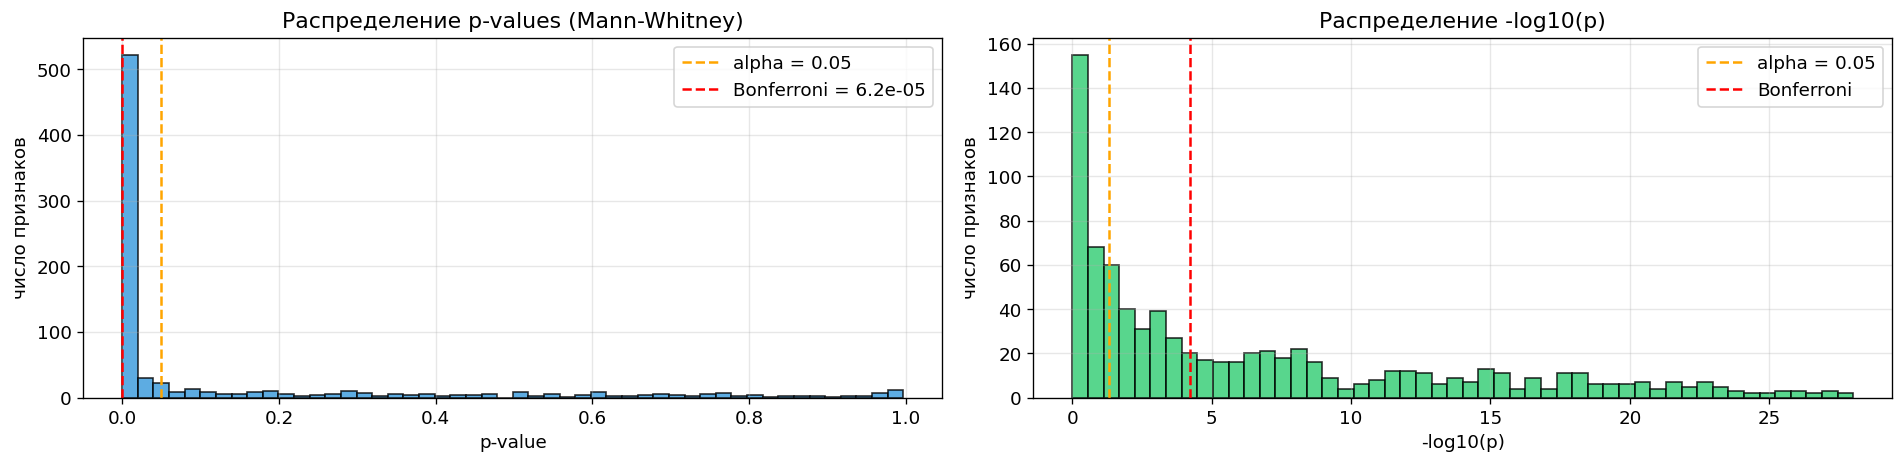

Число значимых признаков (Bonferroni) по типу агрегата:
aggregate
mean_vel_norm    62
std_acc_norm     62
std_vel_norm     62
max_vel_norm     55
std_norm         51
max_acc_norm     43
std_angle        13
max_norm         12
mean_angle       10
range_angle       8
dtype: int64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(mw_df['p_value'], bins=50, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].axvline(alpha, color='orange', ls='--', label=f'alpha = {alpha}')
axes[0].axvline(alpha_bonf, color='red', ls='--', label=f'Bonferroni = {alpha_bonf:.1e}')
axes[0].set_xlabel('p-value'); axes[0].set_ylabel('число признаков')
axes[0].set_title('Распределение p-values (Mann-Whitney)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(mw_df['neg_log10_p'], bins=50, color='#2ecc71', alpha=0.8, edgecolor='black')
axes[1].axvline(-np.log10(alpha), color='orange', ls='--', label=f'alpha = {alpha}')
axes[1].axvline(-np.log10(alpha_bonf), color='red', ls='--', label='Bonferroni')
axes[1].set_xlabel('-log10(p)'); axes[1].set_ylabel('число признаков')
axes[1].set_title('Распределение -log10(p)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

agg_sig = mw_df[mw_df['significant_bonf']].groupby('aggregate').size().sort_values(ascending=False)
print('Число значимых признаков (Bonferroni) по типу агрегата:')
print(agg_sig)


## 3. Функции пайплайна

- `prepare_data(agg_list, include_duration)` — pivot long → wide для dist_-агрегатов
- `prepare_area_data(area_agg_list, include_duration)` — выборка area_-признаков из wide-датасета
- `run_models_xy(X, y, groups)` — CV по 5 моделям, возвращает словарь метрик
- `run_models(agg_list)` / `run_area_models(area_agg_list)` — обёртки с подготовкой данных


In [11]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        cols = list(upper.columns)
        to_drop = set(c for c in cols if any(upper[c] > self.threshold))
        self.keep_mask_ = np.array([c not in to_drop for c in cols])
        return self
    def transform(self, X):
        X_arr = X.values if isinstance(X, pd.DataFrame) else X
        return X_arr[:, self.keep_mask_]


def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'accuracy':          'accuracy',
    'f1':                'f1',
    'roc_auc':           'roc_auc',
    'sensitivity':       'recall',
    'specificity':       make_scorer(specificity_score),
}


def prepare_data(agg_list, include_duration=False):
    """Pivot long-format rows for given dist_-aggregates into a wide matrix."""
    if len(agg_list) == 1:
        sub = df[df['Aggregate'] == agg_list[0]].copy()
        feat = list(dist_cols)
        if include_duration:
            feat = feat + [DURATION_COL]
        return sub[feat], sub['label'], sub['Patient']
    sub = df[df['Aggregate'].isin(agg_list)]
    pivot = sub.pivot_table(index=['Patient','r','label'], columns='Aggregate', values=dist_cols)
    pivot.columns = [f'{f}_{a}' for f, a in pivot.columns]
    pivot = pivot.reset_index()
    feat = [c for c in pivot.columns if c.startswith('dist_')]
    if include_duration:
        dur = df.groupby(['Patient','r'])[DURATION_COL].first().reset_index()
        pivot = pivot.merge(dur, on=['Patient','r'], how='left')
        feat = feat + [DURATION_COL]
    return pivot[feat], pivot['label'], pivot['Patient']


def get_area_feat(area_agg_list):
    """Select area_ columns matching given aggregate suffixes."""
    return [c for c in area_cols if any(c.endswith('_'+s) for s in area_agg_list)]


def prepare_area_data(area_agg_list, include_duration=False):
    """Select area features from wide-format dataset."""
    feat = get_area_feat(area_agg_list)
    cols_need = ['id','r','label'] + ([DURATION_COL] if include_duration else []) + feat
    sub = df_wide[cols_need].rename(columns={'id':'Patient'})
    X = sub[feat + ([DURATION_COL] if include_duration else [])]
    return X, sub['label'], sub['Patient']


def _make_models(y):
    return {
        'LR':   LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        'RF':   RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1),
        'XGB':  XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y==0).sum()/(y==1).sum(),
                              random_state=RANDOM_STATE, eval_metric='logloss'),
        'LGBM': LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.1,
                               class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
        'SVM':  SVC(kernel='rbf', class_weight='balanced', probability=True,
                    random_state=RANDOM_STATE),
    }


def run_models_xy(X, y, groups):
    """CV over 5 models; returns (res_dict, n_feat_after_corr_filter)."""
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models_dict = _make_models(y)
    res = {}
    n_feat_after = None
    for name, model in models_dict.items():
        pipe = Pipeline([
            ('corr',   CorrelationFilter(threshold=0.95)),
            ('scaler', StandardScaler()),
            ('model',  model),
        ])
        cvr = cross_validate(pipe, X, y, groups=groups, cv=cv,
                             scoring=scoring, return_train_score=False,
                             return_estimator=(name == 'LR'))
        if name == 'LR' and n_feat_after is None:
            n_feat_after = int(cvr['estimator'][0].named_steps['corr'].keep_mask_.sum())
        res[name] = {
            'bal_acc':     np.mean(cvr['test_balanced_accuracy']),
            'acc':         np.mean(cvr['test_accuracy']),
            'f1':          np.mean(cvr['test_f1']),
            'roc_auc':     np.mean(cvr['test_roc_auc']),
            'sens':        np.mean(cvr['test_sensitivity']),
            'spec':        np.mean(cvr['test_specificity']),
            'roc_auc_std': np.std(cvr['test_roc_auc']),
            'bal_acc_std': np.std(cvr['test_balanced_accuracy']),
        }
    return res, n_feat_after


def run_models(agg_list, include_duration=False):
    X, y, groups = prepare_data(agg_list, include_duration)
    return run_models_xy(X, y, groups)


def run_area_models(area_agg_list, include_duration=False):
    X, y, groups = prepare_area_data(area_agg_list, include_duration)
    return run_models_xy(X, y, groups)


print('Функции определены.')


Функции определены.


## 4. Проверка CV-схемы

In [13]:
X_cv, y_cv, groups_cv = prepare_data(GEOM_AGGS)
cv_check = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'X: {X_cv.shape},  уникальных пациентов: {groups_cv.nunique()}')
for fold, (tr, te) in enumerate(cv_check.split(X_cv, y_cv, groups_cv)):
    tr_pat = set(groups_cv.iloc[tr])
    te_pat = set(groups_cv.iloc[te])
    print(f'  Fold {fold+1}: train={len(tr_pat)} пац., test={len(te_pat)} пац., '
          f'PD_test={y_cv.iloc[te].sum()}, overlap={len(tr_pat & te_pat)}')


X: (255, 310),  уникальных пациентов: 151
  Fold 1: train=121 пац., test=30 пац., PD_test=29, overlap=0
  Fold 2: train=121 пац., test=30 пац., PD_test=31, overlap=0
  Fold 3: train=122 пац., test=29 пац., PD_test=32, overlap=0
  Fold 4: train=120 пац., test=31 пац., PD_test=33, overlap=0
  Fold 5: train=120 пац., test=31 пац., PD_test=31, overlap=0


---

# Block 2. Исследование по группам агрегатов

Для каждой группы: одиночные агрегаты (таблица + heatmap) → все комбинации (рейтинг + barplot) → лучшая комбинация.


## 5. Геометрические агрегаты

Пять статистик положения ориентира: min, max, mean, median, std — нормированных на межзрачковое расстояние.
Каждый агрегат описывает форму движения с разных сторон: центральная тенденция, разброс, экстремумы.


### 5.1 Одиночные агрегаты

Каждый агрегат группы прогоняется отдельно через все пять моделей.


In [17]:
geom_aggs = GEOM_AGGS
geom_single = {}
for agg in geom_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    geom_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> min_norm
>>> max_norm
>>> mean_norm
>>> median_norm
>>> std_norm
Готово.


In [18]:
# Сводная таблица одиночных агрегатов
rows = []
for agg in geom_aggs:
    r = geom_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({
        'Aggregate':       agg,
        'Features (fold1)': r['n_feat'],
        'Best model':      best_model,
        'Bal.Acc':         best['bal_acc'],
        'ROC-AUC':         best['roc_auc'],
        'Sens':            best['sens'],
        'Spec':            best['spec'],
    })
geom_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(geom_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}',
                                              'Sens':'{:.3f}','Spec':'{:.3f}'}))


,Aggregate,Features (fold1),Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,std_norm,26,RF,0.668,0.767,0.806,0.530
1,max_norm,29,LR,0.679,0.726,0.722,0.637
2,mean_norm,24,LR,0.617,0.646,0.696,0.538
3,median_norm,26,LR,0.579,0.626,0.703,0.456
4,min_norm,26,LR,0.543,0.618,0.619,0.467


### Heatmap: модели × агрегаты (Геометрия)

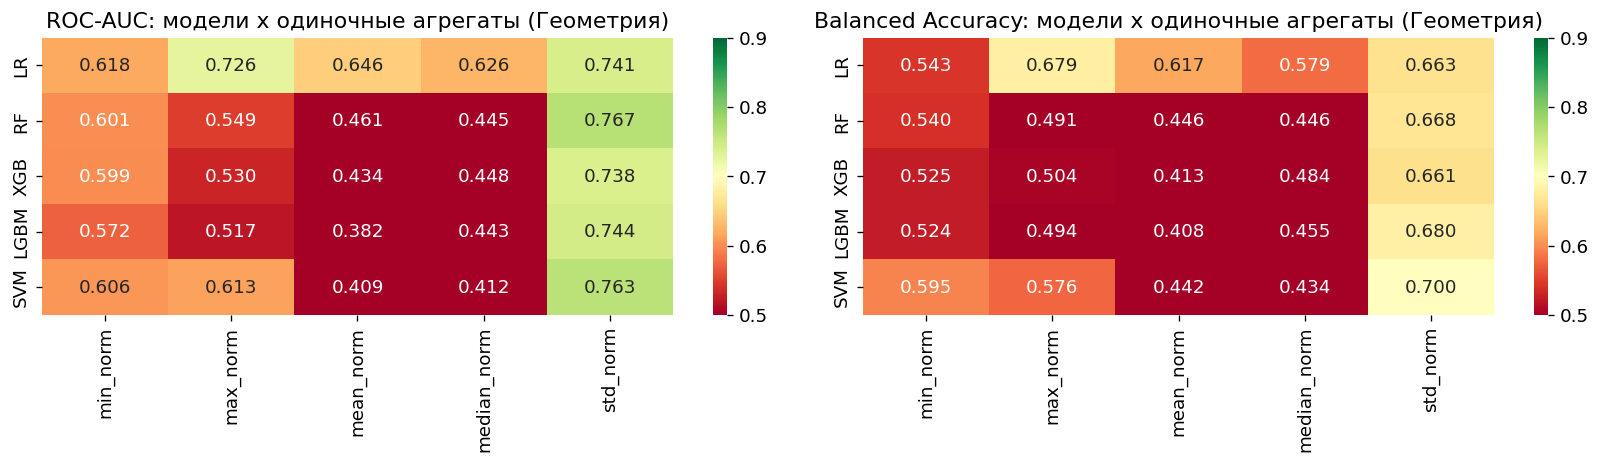

In [20]:
hm_auc_geom = np.zeros((len(model_names), len(geom_aggs)))
hm_bal_geom = np.zeros((len(model_names), len(geom_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(geom_aggs):
        hm_auc_geom[i, j] = geom_single[agg]['res'][mn]['roc_auc']
        hm_bal_geom[i, j] = geom_single[agg]['res'][mn]['bal_acc']

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(geom_aggs)*2+4), 4))
sns.heatmap(hm_auc_geom, xticklabels=geom_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: модели x одиночные агрегаты (Геометрия)')
sns.heatmap(hm_bal_geom, xticklabels=geom_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: модели x одиночные агрегаты (Геометрия)')
plt.tight_layout(); plt.show()


### 5.2 Все комбинации агрегатов

Все непустые подмножества агрегатов группы. Для каждой комбинации — все пять моделей.


In [22]:
geom_combos = dict(geom_single)  # одиночные уже есть
for n_c in range(2, len(geom_aggs) + 1):
    for combo in combinations(geom_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        geom_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'\nВсего комбинаций: {len(geom_combos)}')


>>> min_norm+max_norm
>>> min_norm+mean_norm
>>> min_norm+median_norm
>>> min_norm+std_norm
>>> max_norm+mean_norm
>>> max_norm+median_norm
>>> max_norm+std_norm
>>> mean_norm+median_norm
>>> mean_norm+std_norm
>>> median_norm+std_norm
>>> min_norm+max_norm+mean_norm
>>> min_norm+max_norm+median_norm
>>> min_norm+max_norm+std_norm
>>> min_norm+mean_norm+median_norm
>>> min_norm+mean_norm+std_norm
>>> min_norm+median_norm+std_norm
>>> max_norm+mean_norm+median_norm
>>> max_norm+mean_norm+std_norm
>>> max_norm+median_norm+std_norm
>>> mean_norm+median_norm+std_norm
>>> min_norm+max_norm+mean_norm+median_norm
>>> min_norm+max_norm+mean_norm+std_norm
>>> min_norm+max_norm+median_norm+std_norm
>>> min_norm+mean_norm+median_norm+std_norm
>>> max_norm+mean_norm+median_norm+std_norm
>>> min_norm+max_norm+mean_norm+median_norm+std_norm

Всего комбинаций: 31


In [23]:
# Рейтинг комбинаций
combo_rows_geom = []
for combo_name, data in geom_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_geom.append({
        'Aggregates':  combo_name,
        'N_agg':       combo_name.count('+')+1,
        'Features':    data['n_feat'],
        'Best model':  best_model,
        'Bal.Acc':     best['bal_acc'],
        'F1':          best['f1'],
        'ROC-AUC':     best['roc_auc'],
        'Sens':        best['sens'],
        'Spec':        best['spec'],
    })
geom_combo_df = (pd.DataFrame(combo_rows_geom)
                         .sort_values('ROC-AUC', ascending=False)
                         .reset_index(drop=True))
print(f'Рейтинг комбинаций (Геометрия):')
display(geom_combo_df.style.format(
    {'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


Рейтинг комбинаций (Геометрия):


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,min_norm+std_norm,2,52,SVM,0.724,0.776,0.798,0.773,0.675
1,min_norm+max_norm+std_norm,3,81,RF,0.672,0.783,0.773,0.868,0.475
2,max_norm+std_norm,2,55,RF,0.683,0.787,0.771,0.856,0.511
3,min_norm+median_norm+std_norm,3,78,SVM,0.689,0.768,0.770,0.792,0.586
4,std_norm,1,26,RF,0.668,0.765,0.767,0.806,0.530
5,max_norm+median_norm+std_norm,3,81,LR,0.720,0.776,0.764,0.784,0.655
6,min_norm+max_norm+median_norm+std_norm,4,107,LR,0.672,0.752,0.760,0.772,0.573
7,median_norm+std_norm,2,52,RF,0.627,0.760,0.759,0.843,0.410
8,min_norm+mean_norm+median_norm+std_norm,4,77,RF,0.657,0.778,0.757,0.857,0.456
9,min_norm+mean_norm+std_norm,3,76,LGBM,0.689,0.773,0.754,0.811,0.566


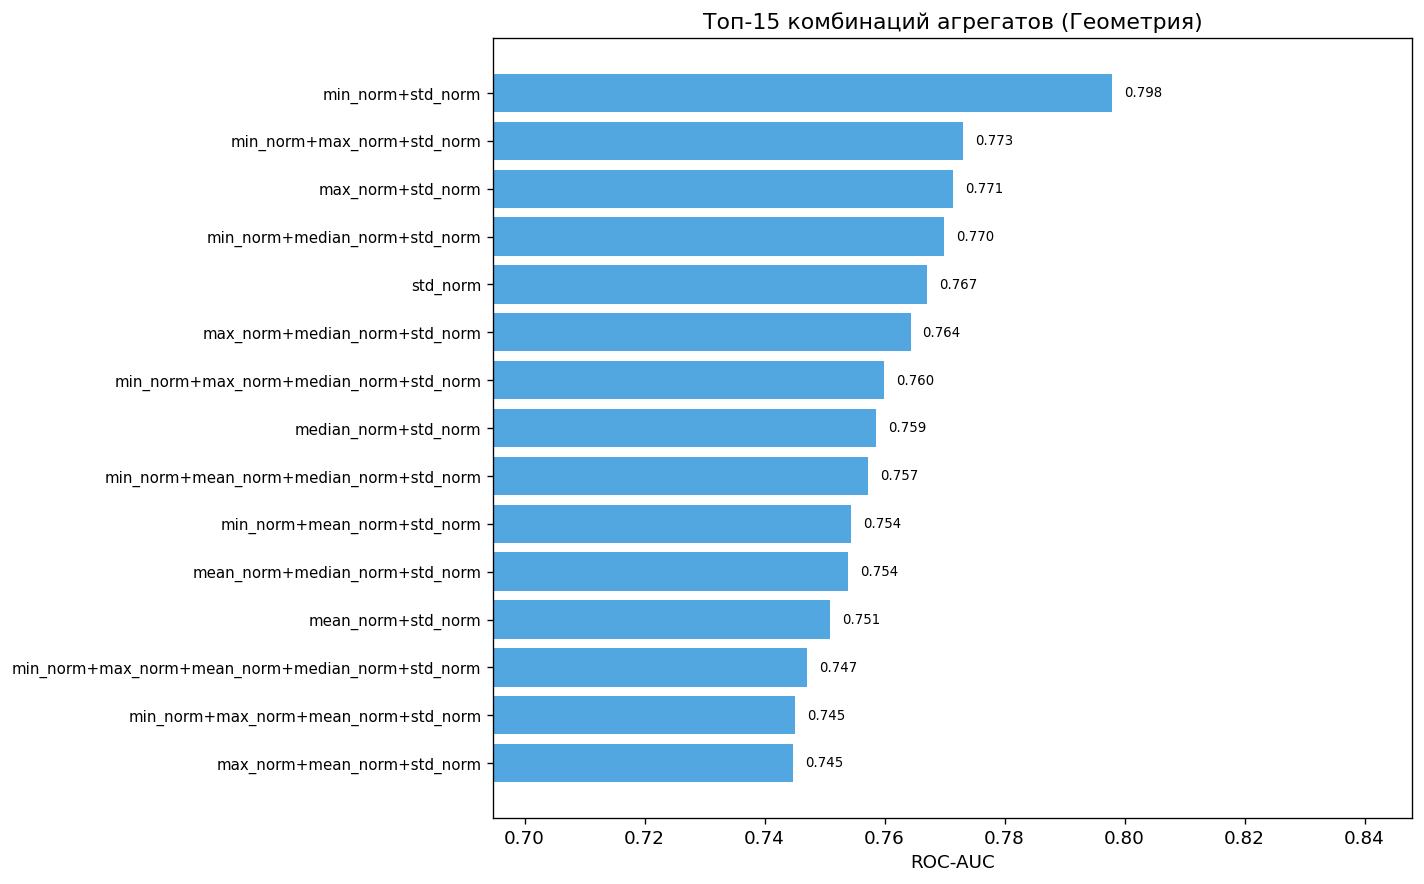

In [24]:
# Топ-15 комбинаций — barplot
top_n = min(15, len(geom_combo_df))
top = geom_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#3498db', alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC')
ax.set_title(f'Топ-{top_n} комбинаций агрегатов (Геометрия)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


### 5.3 Детальная оценка лучшей комбинации (Геометрия)

In [26]:
geom_best_name  = geom_combo_df.iloc[0]['Aggregates']
geom_best_model_name = geom_combo_df.iloc[0]['Best model']
print(f'Лучшая комбинация: {geom_best_name}')
print(f'Лучшая модель:     {geom_best_model_name}')

geom_best_list = geom_best_name.split('+')
X_geom, y_geom, g_geom = prepare_data(geom_best_list)

cf_tmp = CorrelationFilter(0.95).fit(X_geom)
print(f'Признаков до фильтра: {X_geom.shape[1]}')
print(f'Признаков после фильтра: {cf_tmp.keep_mask_.sum()}')

cv_best = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_map_geom = _make_models(y_geom.values)
best_m_geom = model_map_geom[geom_best_model_name]

oof_preds_geom = np.zeros(len(y_geom))
oof_proba_geom = np.zeros(len(y_geom))
for tr, te in cv_best.split(X_geom, y_geom, g_geom):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_m_geom))])
    pipe.fit(X_geom.iloc[tr], y_geom.iloc[tr])
    oof_preds_geom[te] = pipe.predict(X_geom.iloc[te])
    oof_proba_geom[te] = pipe.predict_proba(X_geom.iloc[te])[:, 1]

print(classification_report(y_geom, oof_preds_geom, target_names=['Healthy','PD']))


Лучшая комбинация: min_norm+std_norm
Лучшая модель:     SVM
Признаков до фильтра: 124
Признаков после фильтра: 55
              precision    recall  f1-score   support

     Healthy       0.65      0.66      0.65        99
          PD       0.78      0.78      0.78       156

    accuracy                           0.73       255
   macro avg       0.72      0.72      0.72       255
weighted avg       0.73      0.73      0.73       255



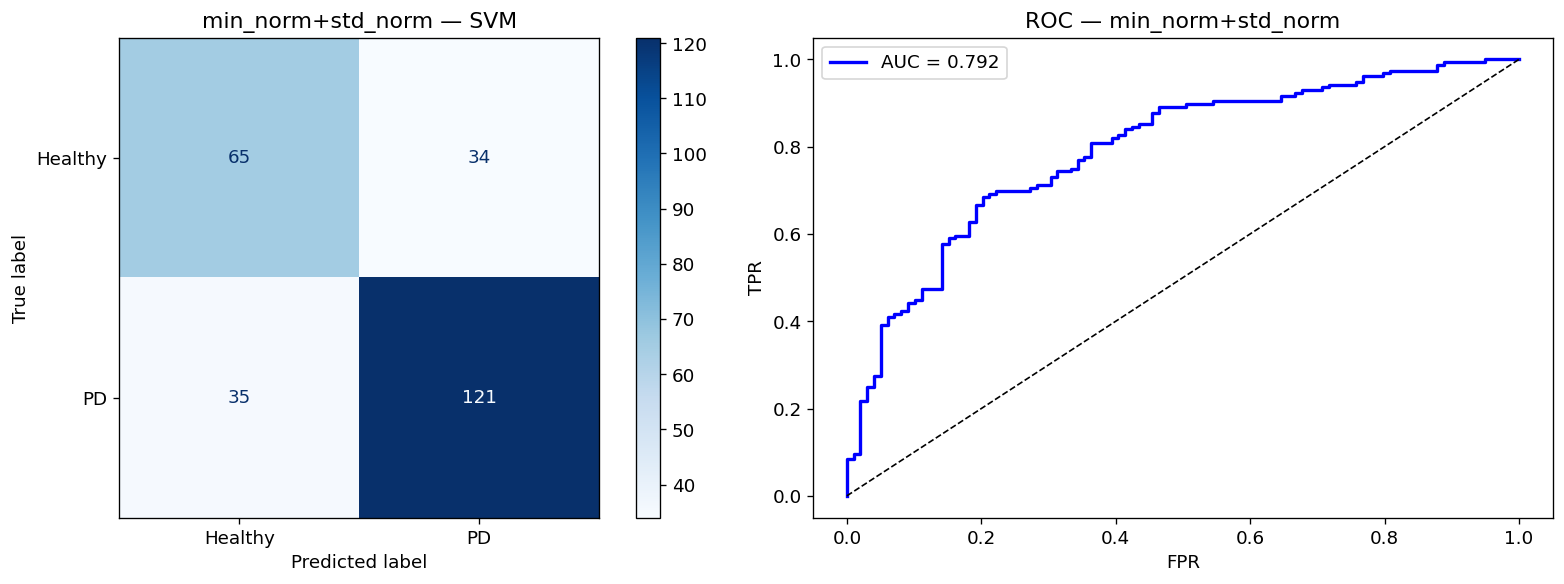

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_geom, oof_preds_geom)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{geom_best_name} — {geom_best_model_name}')

fpr, tpr, _ = roc_curve(y_geom, oof_proba_geom)
auc_val = roc_auc_score(y_geom, oof_proba_geom)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {geom_best_name}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 6. Динамические агрегаты (скорость + ускорение)

Пять агрегатов динамики: max_vel_norm, mean_vel_norm, std_vel_norm (скорость), max_acc_norm, std_acc_norm (ускорение).
Описывают темп и характер движения лица при улыбке, а не только конечное положение.


### 6.1 Одиночные агрегаты

Каждый агрегат группы прогоняется отдельно через все пять моделей.


In [30]:
dyn_aggs = DYN_AGGS
dyn_single = {}
for agg in dyn_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    dyn_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> max_vel_norm
>>> mean_vel_norm
>>> std_vel_norm
>>> max_acc_norm
>>> std_acc_norm
Готово.


In [31]:
# Сводная таблица одиночных агрегатов
rows = []
for agg in dyn_aggs:
    r = dyn_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({
        'Aggregate':       agg,
        'Features (fold1)': r['n_feat'],
        'Best model':      best_model,
        'Bal.Acc':         best['bal_acc'],
        'ROC-AUC':         best['roc_auc'],
        'Sens':            best['sens'],
        'Spec':            best['spec'],
    })
dyn_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(dyn_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}',
                                              'Sens':'{:.3f}','Spec':'{:.3f}'}))


,Aggregate,Features (fold1),Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,mean_vel_norm,10,LR,0.813,0.885,0.806,0.819
1,std_vel_norm,11,LR,0.778,0.854,0.774,0.783
2,std_acc_norm,14,RF,0.736,0.799,0.807,0.665
3,max_vel_norm,23,RF,0.647,0.723,0.767,0.527
4,max_acc_norm,22,RF,0.595,0.681,0.761,0.428


### Heatmap: модели × агрегаты (Динамика)

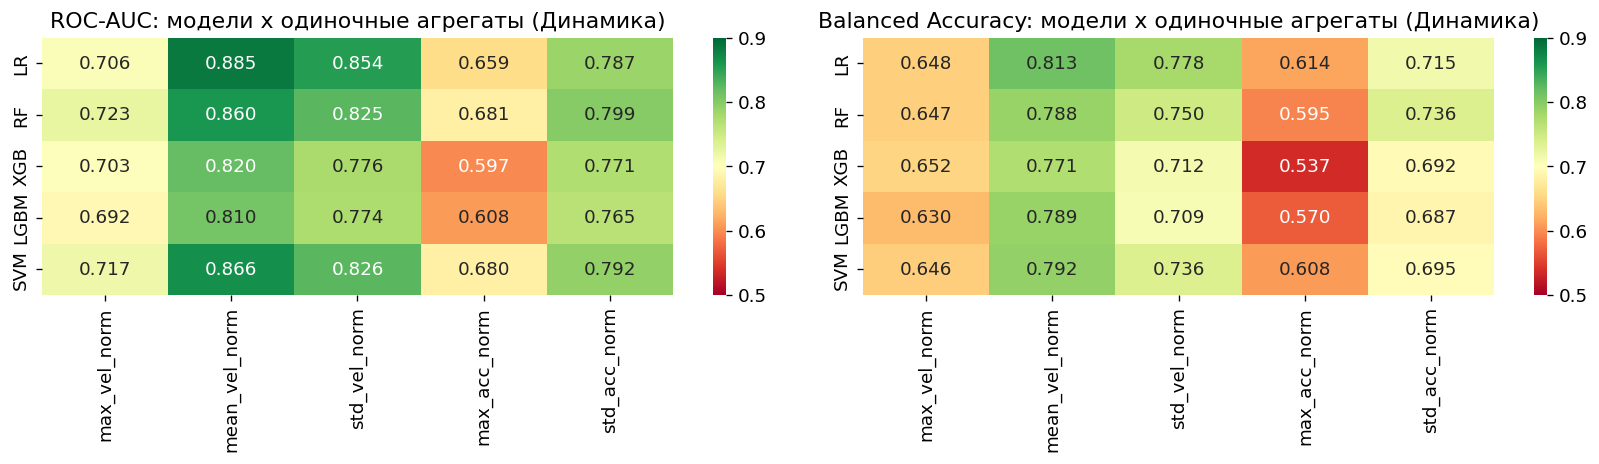

In [33]:
hm_auc_dyn = np.zeros((len(model_names), len(dyn_aggs)))
hm_bal_dyn = np.zeros((len(model_names), len(dyn_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(dyn_aggs):
        hm_auc_dyn[i, j] = dyn_single[agg]['res'][mn]['roc_auc']
        hm_bal_dyn[i, j] = dyn_single[agg]['res'][mn]['bal_acc']

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(dyn_aggs)*2+4), 4))
sns.heatmap(hm_auc_dyn, xticklabels=dyn_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: модели x одиночные агрегаты (Динамика)')
sns.heatmap(hm_bal_dyn, xticklabels=dyn_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: модели x одиночные агрегаты (Динамика)')
plt.tight_layout(); plt.show()


### 6.2 Все комбинации агрегатов

Все непустые подмножества агрегатов группы. Для каждой комбинации — все пять моделей.


In [35]:
dyn_combos = dict(dyn_single)  # одиночные уже есть
for n_c in range(2, len(dyn_aggs) + 1):
    for combo in combinations(dyn_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        dyn_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'\nВсего комбинаций: {len(dyn_combos)}')


>>> max_vel_norm+mean_vel_norm
>>> max_vel_norm+std_vel_norm
>>> max_vel_norm+max_acc_norm
>>> max_vel_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm
>>> mean_vel_norm+max_acc_norm
>>> mean_vel_norm+std_acc_norm
>>> std_vel_norm+max_acc_norm
>>> std_vel_norm+std_acc_norm
>>> max_acc_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm
>>> max_vel_norm+mean_vel_norm+max_acc_norm
>>> max_vel_norm+mean_vel_norm+std_acc_norm
>>> max_vel_norm+std_vel_norm+max_acc_norm
>>> max_vel_norm+std_vel_norm+std_acc_norm
>>> max_vel_norm+max_acc_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm+max_acc_norm
>>> mean_vel_norm+std_vel_norm+std_acc_norm
>>> mean_vel_norm+max_acc_norm+std_acc_norm
>>> std_vel_norm+max_acc_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm+max_acc_norm
>>> max_vel_norm+mean_vel_norm+std_vel_norm+std_acc_norm
>>> max_vel_norm+mean_vel_norm+max_acc_norm+std_acc_norm
>>> max_vel_norm+std_vel_norm+max_acc_norm+std_acc_norm
>>> mean_vel_norm+std_vel_norm+ma

In [36]:
# Рейтинг комбинаций
combo_rows_dyn = []
for combo_name, data in dyn_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_dyn.append({
        'Aggregates':  combo_name,
        'N_agg':       combo_name.count('+')+1,
        'Features':    data['n_feat'],
        'Best model':  best_model,
        'Bal.Acc':     best['bal_acc'],
        'F1':          best['f1'],
        'ROC-AUC':     best['roc_auc'],
        'Sens':        best['sens'],
        'Spec':        best['spec'],
    })
dyn_combo_df = (pd.DataFrame(combo_rows_dyn)
                         .sort_values('ROC-AUC', ascending=False)
                         .reset_index(drop=True))
print(f'Рейтинг комбинаций (Динамика):')
display(dyn_combo_df.style.format(
    {'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


Рейтинг комбинаций (Динамика):


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,max_vel_norm+mean_vel_norm+std_vel_norm,3,35,LR,0.825,0.852,0.891,0.831,0.819
1,max_vel_norm+mean_vel_norm,2,33,LR,0.821,0.849,0.891,0.831,0.810
2,max_vel_norm+std_vel_norm+std_acc_norm,3,42,LR,0.813,0.849,0.891,0.844,0.782
3,mean_vel_norm+std_vel_norm,2,12,LR,0.813,0.843,0.887,0.825,0.801
4,max_vel_norm+mean_vel_norm+std_vel_norm+std_acc_norm,4,47,LR,0.813,0.838,0.886,0.816,0.809
5,max_vel_norm+mean_vel_norm+std_acc_norm,3,46,LR,0.809,0.834,0.885,0.810,0.809
6,mean_vel_norm,1,10,LR,0.813,0.835,0.885,0.806,0.819
7,max_vel_norm+std_vel_norm,2,34,LR,0.808,0.840,0.882,0.825,0.792
8,mean_vel_norm+std_acc_norm,2,23,LR,0.788,0.824,0.879,0.812,0.764
9,mean_vel_norm+std_vel_norm+std_acc_norm,3,24,LR,0.783,0.822,0.878,0.812,0.755


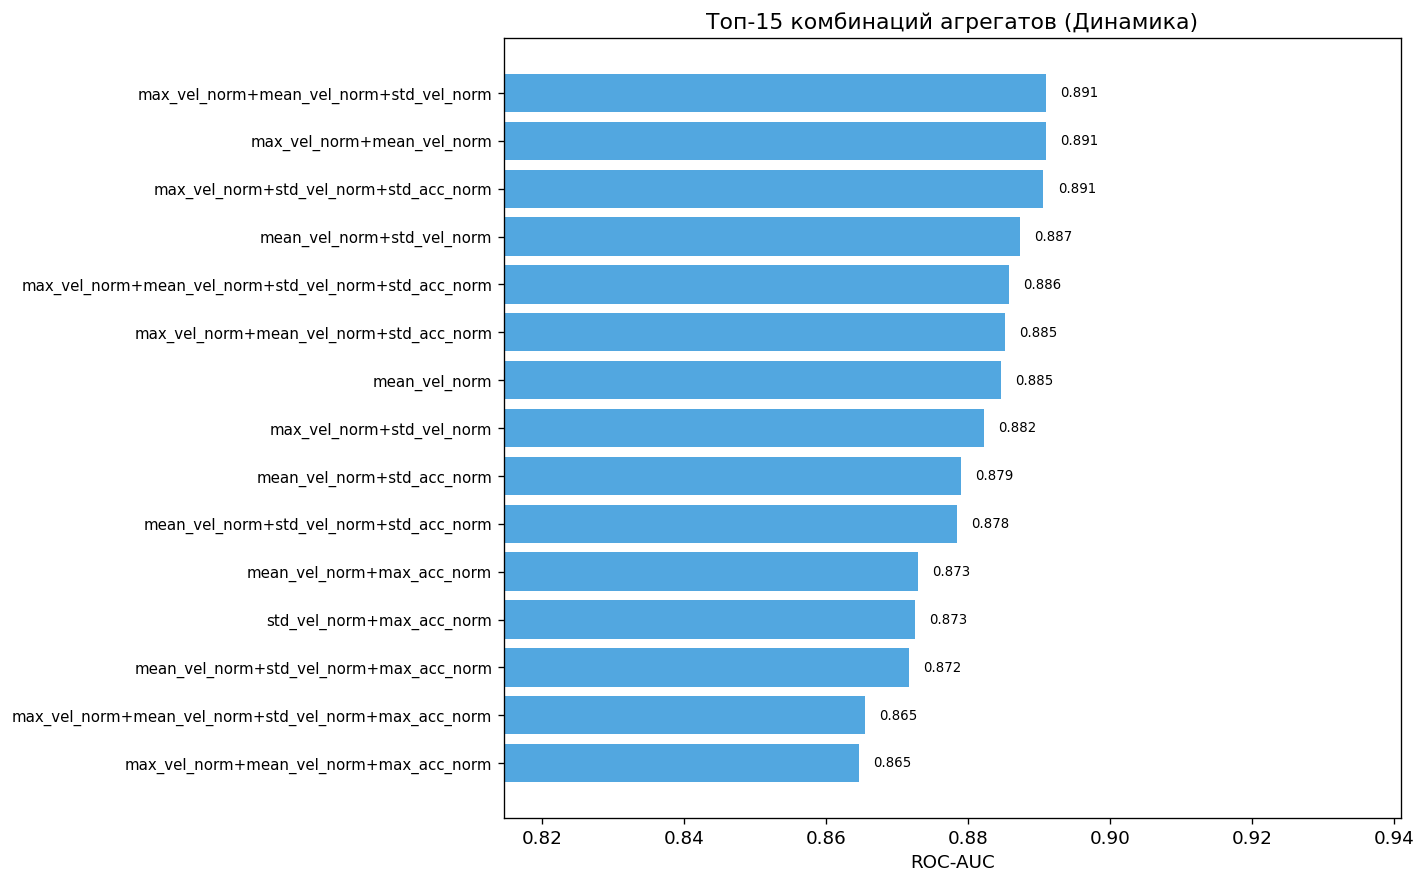

In [37]:
# Топ-15 комбинаций — barplot
top_n = min(15, len(dyn_combo_df))
top = dyn_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#3498db', alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC')
ax.set_title(f'Топ-{top_n} комбинаций агрегатов (Динамика)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


### 6.3 Детальная оценка лучшей комбинации (Динамика)

In [39]:
dyn_best_name  = dyn_combo_df.iloc[0]['Aggregates']
dyn_best_model_name = dyn_combo_df.iloc[0]['Best model']
print(f'Лучшая комбинация: {dyn_best_name}')
print(f'Лучшая модель:     {dyn_best_model_name}')

dyn_best_list = dyn_best_name.split('+')
X_dyn, y_dyn, g_dyn = prepare_data(dyn_best_list)

cf_tmp = CorrelationFilter(0.95).fit(X_dyn)
print(f'Признаков до фильтра: {X_dyn.shape[1]}')
print(f'Признаков после фильтра: {cf_tmp.keep_mask_.sum()}')

cv_best = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_map_dyn = _make_models(y_dyn.values)
best_m_dyn = model_map_dyn[dyn_best_model_name]

oof_preds_dyn = np.zeros(len(y_dyn))
oof_proba_dyn = np.zeros(len(y_dyn))
for tr, te in cv_best.split(X_dyn, y_dyn, g_dyn):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_m_dyn))])
    pipe.fit(X_dyn.iloc[tr], y_dyn.iloc[tr])
    oof_preds_dyn[te] = pipe.predict(X_dyn.iloc[te])
    oof_proba_dyn[te] = pipe.predict_proba(X_dyn.iloc[te])[:, 1]

print(classification_report(y_dyn, oof_preds_dyn, target_names=['Healthy','PD']))


Лучшая комбинация: max_vel_norm+mean_vel_norm+std_vel_norm
Лучшая модель:     LR
Признаков до фильтра: 186
Признаков после фильтра: 37
              precision    recall  f1-score   support

     Healthy       0.76      0.82      0.79        99
          PD       0.88      0.83      0.86       156

    accuracy                           0.83       255
   macro avg       0.82      0.83      0.82       255
weighted avg       0.83      0.83      0.83       255



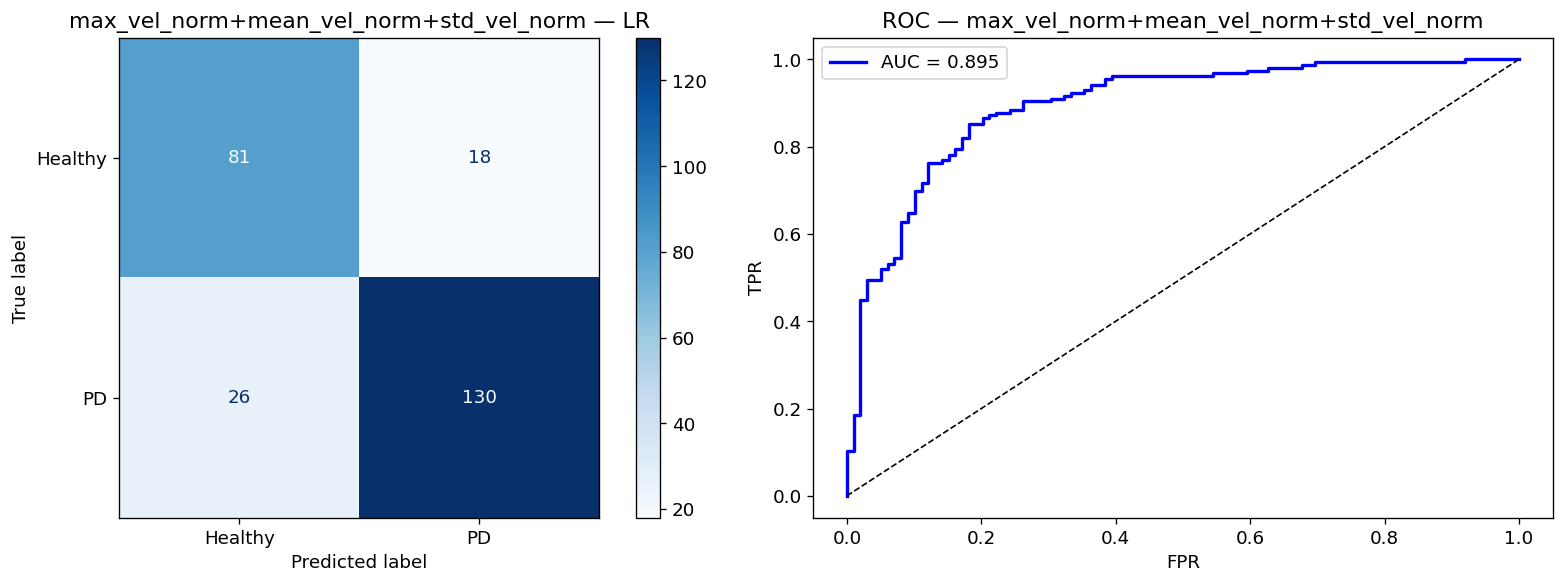

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_dyn, oof_preds_dyn)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{dyn_best_name} — {dyn_best_model_name}')

fpr, tpr, _ = roc_curve(y_dyn, oof_proba_dyn)
auc_val = roc_auc_score(y_dyn, oof_proba_dyn)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {dyn_best_name}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 7. Угловые агрегаты

Три агрегата углов между последовательными векторами движения: mean_angle, std_angle, range_angle.
Отражают плавность и направленность движения при улыбке.


### 7.1 Одиночные агрегаты

Каждый агрегат группы прогоняется отдельно через все пять моделей.


In [43]:
ang_aggs = ANG_AGGS
ang_single = {}
for agg in ang_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_models([agg])
    ang_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> mean_angle
>>> std_angle
>>> range_angle
Готово.


In [44]:
# Сводная таблица одиночных агрегатов
rows = []
for agg in ang_aggs:
    r = ang_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({
        'Aggregate':       agg,
        'Features (fold1)': r['n_feat'],
        'Best model':      best_model,
        'Bal.Acc':         best['bal_acc'],
        'ROC-AUC':         best['roc_auc'],
        'Sens':            best['sens'],
        'Spec':            best['spec'],
    })
ang_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(ang_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}',
                                              'Sens':'{:.3f}','Spec':'{:.3f}'}))


,Aggregate,Features (fold1),Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,std_angle,48,LR,0.611,0.680,0.720,0.502
1,mean_angle,22,LR,0.632,0.668,0.686,0.577
2,range_angle,35,RF,0.595,0.666,0.859,0.331


### Heatmap: модели × агрегаты (Углы)

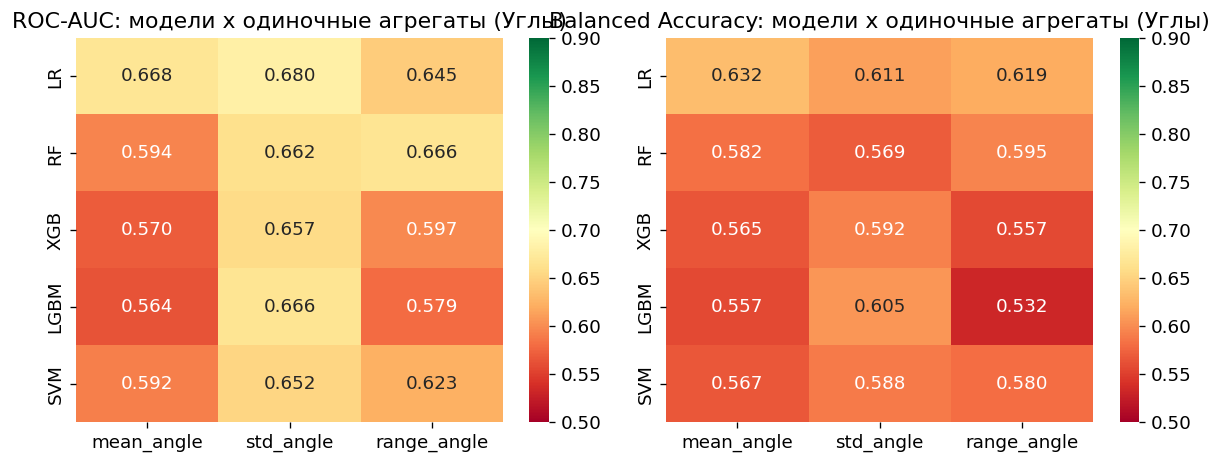

In [46]:
hm_auc_ang = np.zeros((len(model_names), len(ang_aggs)))
hm_bal_ang = np.zeros((len(model_names), len(ang_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(ang_aggs):
        hm_auc_ang[i, j] = ang_single[agg]['res'][mn]['roc_auc']
        hm_bal_ang[i, j] = ang_single[agg]['res'][mn]['bal_acc']

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(ang_aggs)*2+4), 4))
sns.heatmap(hm_auc_ang, xticklabels=ang_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: модели x одиночные агрегаты (Углы)')
sns.heatmap(hm_bal_ang, xticklabels=ang_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: модели x одиночные агрегаты (Углы)')
plt.tight_layout(); plt.show()


### 7.2 Все комбинации агрегатов

Все непустые подмножества агрегатов группы. Для каждой комбинации — все пять моделей.


In [48]:
ang_combos = dict(ang_single)  # одиночные уже есть
for n_c in range(2, len(ang_aggs) + 1):
    for combo in combinations(ang_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_models(list(combo))
        ang_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'\nВсего комбинаций: {len(ang_combos)}')


>>> mean_angle+std_angle
>>> mean_angle+range_angle
>>> std_angle+range_angle
>>> mean_angle+std_angle+range_angle

Всего комбинаций: 7


In [49]:
# Рейтинг комбинаций
combo_rows_ang = []
for combo_name, data in ang_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_ang.append({
        'Aggregates':  combo_name,
        'N_agg':       combo_name.count('+')+1,
        'Features':    data['n_feat'],
        'Best model':  best_model,
        'Bal.Acc':     best['bal_acc'],
        'F1':          best['f1'],
        'ROC-AUC':     best['roc_auc'],
        'Sens':        best['sens'],
        'Spec':        best['spec'],
    })
ang_combo_df = (pd.DataFrame(combo_rows_ang)
                         .sort_values('ROC-AUC', ascending=False)
                         .reset_index(drop=True))
print(f'Рейтинг комбинаций (Углы):')
display(ang_combo_df.style.format(
    {'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


Рейтинг комбинаций (Углы):


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,mean_angle+std_angle,2,70,LR,0.651,0.747,0.701,0.774,0.528
1,mean_angle+std_angle+range_angle,3,100,LR,0.649,0.735,0.694,0.743,0.554
2,std_angle,1,48,LR,0.611,0.704,0.680,0.720,0.502
3,std_angle+range_angle,2,78,XGB,0.593,0.709,0.671,0.748,0.438
4,mean_angle,1,22,LR,0.632,0.707,0.668,0.686,0.577
5,mean_angle+range_angle,2,57,LR,0.623,0.712,0.667,0.719,0.527
6,range_angle,1,35,RF,0.595,0.757,0.666,0.859,0.331


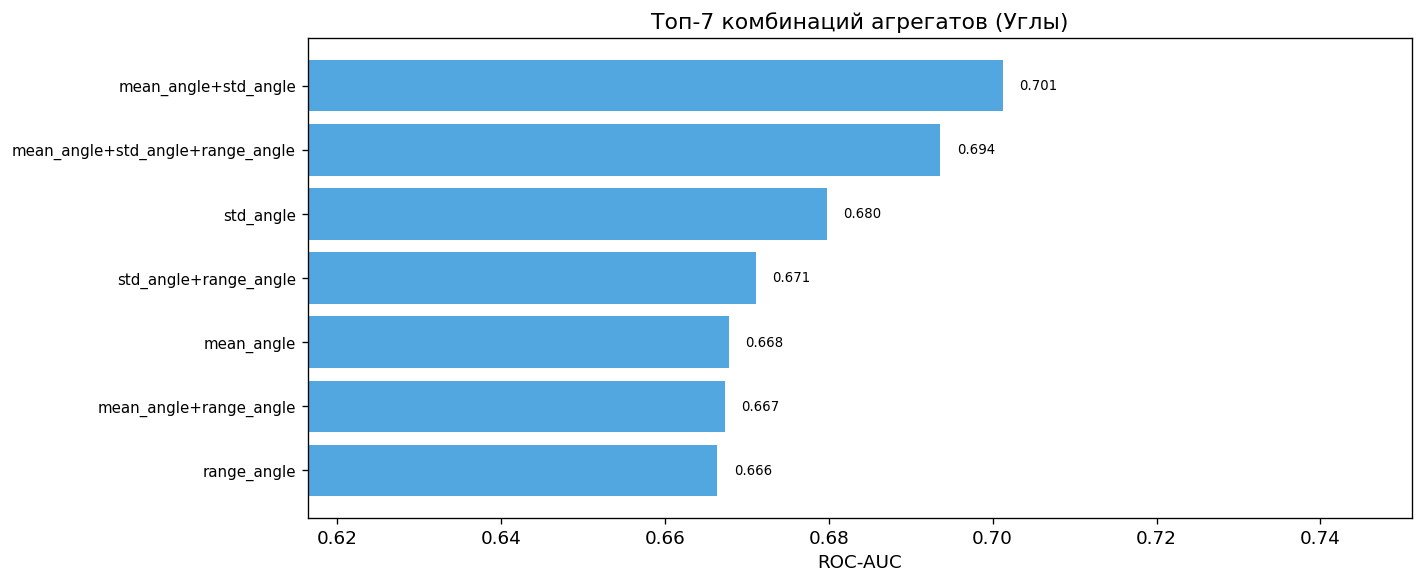

In [50]:
# Топ-15 комбинаций — barplot
top_n = min(15, len(ang_combo_df))
top = ang_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#3498db', alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC')
ax.set_title(f'Топ-{top_n} комбинаций агрегатов (Углы)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


### 7.3 Детальная оценка лучшей комбинации (Углы)

In [52]:
ang_best_name  = ang_combo_df.iloc[0]['Aggregates']
ang_best_model_name = ang_combo_df.iloc[0]['Best model']
print(f'Лучшая комбинация: {ang_best_name}')
print(f'Лучшая модель:     {ang_best_model_name}')

ang_best_list = ang_best_name.split('+')
X_ang, y_ang, g_ang = prepare_data(ang_best_list)

cf_tmp = CorrelationFilter(0.95).fit(X_ang)
print(f'Признаков до фильтра: {X_ang.shape[1]}')
print(f'Признаков после фильтра: {cf_tmp.keep_mask_.sum()}')

cv_best = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_map_ang = _make_models(y_ang.values)
best_m_ang = model_map_ang[ang_best_model_name]

oof_preds_ang = np.zeros(len(y_ang))
oof_proba_ang = np.zeros(len(y_ang))
for tr, te in cv_best.split(X_ang, y_ang, g_ang):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_m_ang))])
    pipe.fit(X_ang.iloc[tr], y_ang.iloc[tr])
    oof_preds_ang[te] = pipe.predict(X_ang.iloc[te])
    oof_proba_ang[te] = pipe.predict_proba(X_ang.iloc[te])[:, 1]

print(classification_report(y_ang, oof_preds_ang, target_names=['Healthy','PD']))


Лучшая комбинация: mean_angle+std_angle
Лучшая модель:     LR
Признаков до фильтра: 124
Признаков после фильтра: 64
              precision    recall  f1-score   support

     Healthy       0.60      0.54      0.57        99
          PD       0.72      0.78      0.75       156

    accuracy                           0.68       255
   macro avg       0.66      0.66      0.66       255
weighted avg       0.68      0.68      0.68       255



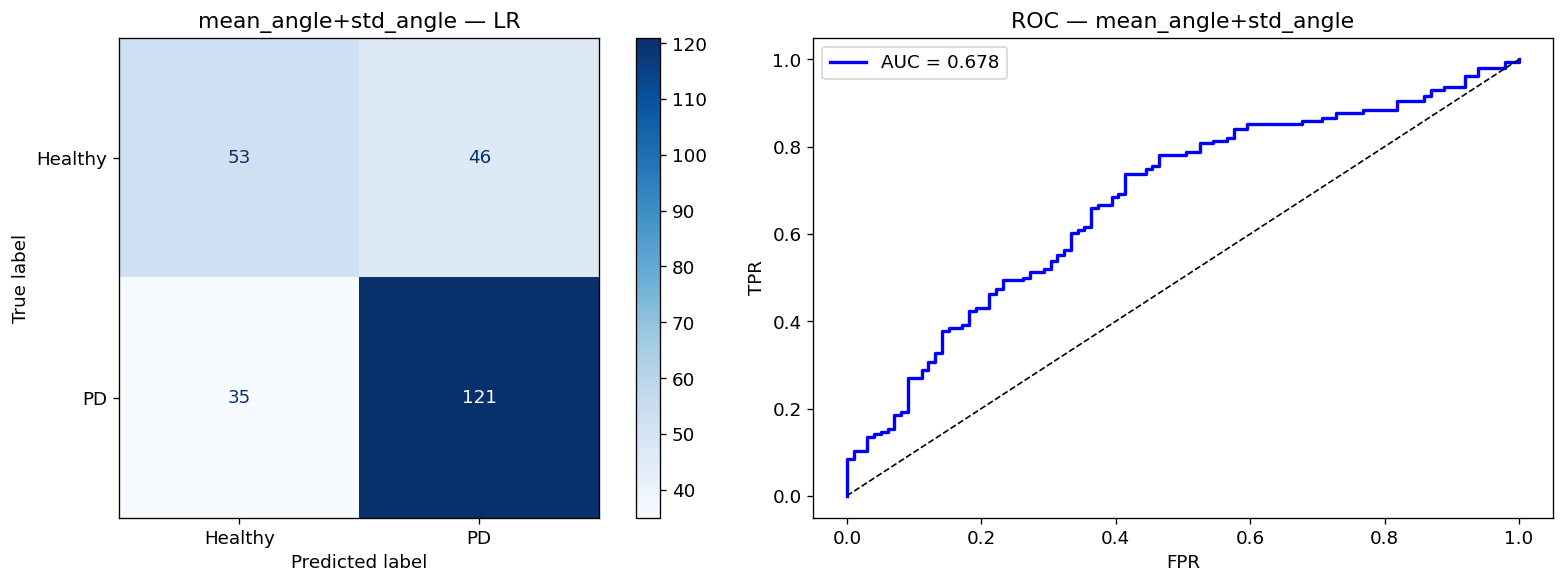

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_ang, oof_preds_ang)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{ang_best_name} — {ang_best_model_name}')

fpr, tpr, _ = roc_curve(y_ang, oof_proba_ang)
auc_val = roc_auc_score(y_ang, oof_proba_ang)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {ang_best_name}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 8. Площадные признаки

68 треугольников из 6 групп landmarks улыбки × 6 агрегатов (min/max/mean/median/std/range площади).
Площади нормированы на квадрат межзрачкового расстояния. Источник: wide-датасет.


### 8.0 Схема треугольников на лице

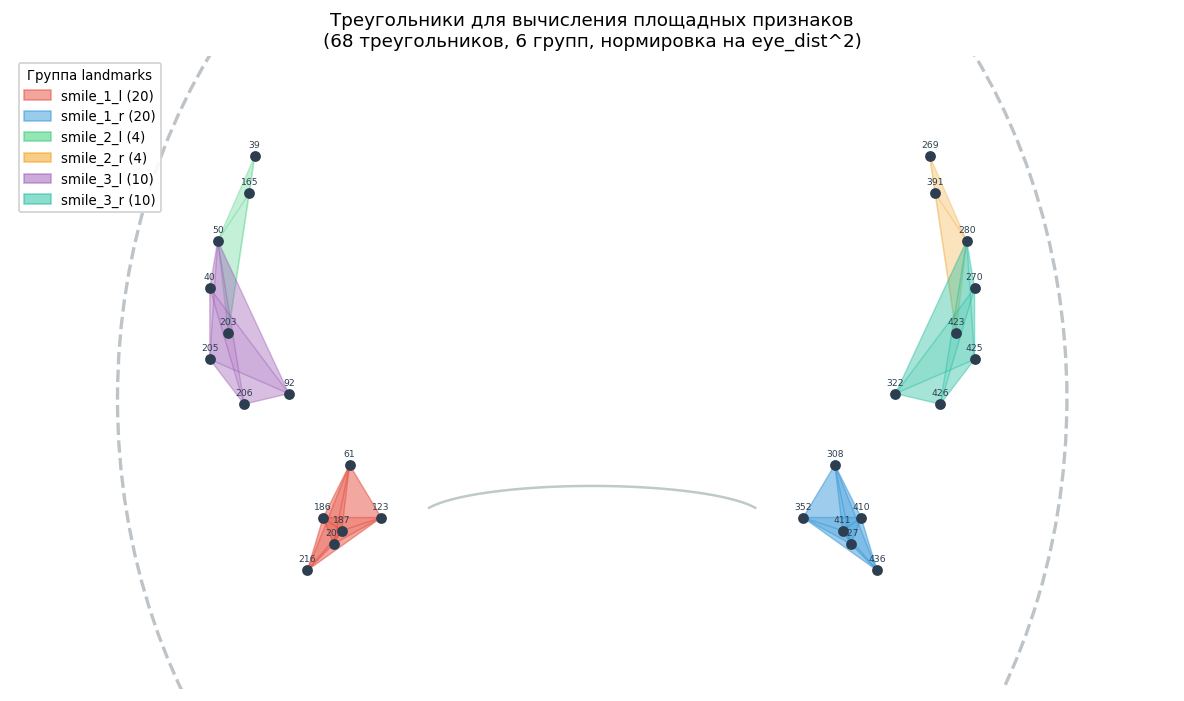

Итого треугольников: 68
Агрегаты площадей: ['area_min', 'area_max', 'area_mean', 'area_median', 'area_std', 'area_range']
Всего area_ признаков: 408  (68 * 6 = 408)


In [56]:
COORDS_VIS = {
    61:(0.408,0.675), 186:(0.398,0.695), 216:(0.392,0.715), 207:(0.402,0.705),
    187:(0.405,0.700), 123:(0.420,0.695),
    308:(0.592,0.675), 410:(0.602,0.695), 436:(0.608,0.715), 427:(0.598,0.705),
    411:(0.595,0.700), 352:(0.580,0.695),
    50:(0.358,0.590),  203:(0.362,0.625), 165:(0.370,0.572), 39:(0.372,0.558),
    280:(0.642,0.590), 423:(0.638,0.625), 391:(0.630,0.572), 269:(0.628,0.558),
    205:(0.355,0.635), 206:(0.368,0.652), 92:(0.385,0.648),  40:(0.355,0.608),
    425:(0.645,0.635), 426:(0.632,0.652), 322:(0.615,0.648), 270:(0.645,0.608),
}
GROUPS_VIS = {
    'smile_1_l (20)': ([61,186,216,207,187,123], '#e74c3c'),
    'smile_1_r (20)': ([308,410,436,427,411,352], '#3498db'),
    'smile_2_l (4)':  ([50,203,165,39],           '#2ecc71'),
    'smile_2_r (4)':  ([280,423,391,269],          '#f39c12'),
    'smile_3_l (10)': ([50,205,206,92,40],         '#9b59b6'),
    'smile_3_r (10)': ([280,425,426,322,270],       '#1abc9c'),
}

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0.28, 0.72); ax.set_ylim(0.52, 0.76)
ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
ax.set_facecolor('#f8f9fa')

face_ell = mpatches.Ellipse((0.5, 0.65), width=0.36, height=0.44,
                             fill=False, edgecolor='#bdc3c7', linewidth=2, linestyle='--')
ax.add_patch(face_ell)
theta = np.linspace(np.pi*0.1, np.pi*0.9, 40)
ax.plot(0.5 + 0.065*np.cos(theta), 0.695 - 0.012*np.sin(theta),
        color='#95a5a6', linewidth=1.5, alpha=0.6)

for g_label, (pts, color) in GROUPS_VIS.items():
    for tri in combinations(pts, 3):
        coords = [COORDS_VIS[p] for p in tri]
        ax.add_patch(plt.Polygon(coords, closed=True, alpha=0.15,
                                 facecolor=color, edgecolor=color, linewidth=0.8))

xs = [v[0] for v in COORDS_VIS.values()]
ys = [v[1] for v in COORDS_VIS.values()]
ax.scatter(xs, ys, s=30, color='#2c3e50', zorder=5)
for lm, (x, y) in COORDS_VIS.items():
    ax.annotate(str(lm), (x, y), fontsize=13, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points', color='#2c3e50')

handles = [mpatches.Patch(color=c, alpha=0.5, label=g)
           for g, (_, c) in GROUPS_VIS.items()]
ax.legend(handles=handles, loc='upper left', fontsize=13, framealpha=0.9,
          title='Группа landmarks', title_fontsize=13)
ax.set_title('Треугольники для вычисления площадных признаков\n'
             f'(68 треугольников, 6 групп, нормировка на eye_dist^2)', fontsize=13)
plt.tight_layout(); plt.show()

n_tri = sum(len(list(combinations(pts,3))) for _,(pts,_) in GROUPS_VIS.items())
print(f'Итого треугольников: {n_tri}')
print(f'Агрегаты площадей: {AREA_AGGS}')
print(f'Всего area_ признаков: {len(area_cols)}  ({n_tri} * {len(AREA_AGGS)} = {n_tri*len(AREA_AGGS)})')


### 8.1 Одиночные агрегаты

Каждый агрегат группы прогоняется отдельно через все пять моделей.


In [58]:
area_aggs = AREA_AGGS
area_single = {}
for agg in area_aggs:
    print(f'>>> {agg}')
    res, n_feat = run_area_models([agg])
    area_single[agg] = {'res': res, 'n_feat': n_feat}
print('Готово.')


>>> area_min
>>> area_max
>>> area_mean
>>> area_median
>>> area_std
>>> area_range
Готово.


In [59]:
# Сводная таблица одиночных агрегатов
rows = []
for agg in area_aggs:
    r = area_single[agg]
    best_model = max(r['res'], key=lambda m: r['res'][m]['roc_auc'])
    best = r['res'][best_model]
    rows.append({
        'Aggregate':       agg,
        'Features (fold1)': r['n_feat'],
        'Best model':      best_model,
        'Bal.Acc':         best['bal_acc'],
        'ROC-AUC':         best['roc_auc'],
        'Sens':            best['sens'],
        'Spec':            best['spec'],
    })
area_single_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(area_single_df.style.format({'Bal.Acc':'{:.3f}','ROC-AUC':'{:.3f}',
                                              'Sens':'{:.3f}','Spec':'{:.3f}'}))


,Aggregate,Features (fold1),Best model,Bal.Acc,ROC-AUC,Sens,Spec
0,area_range,54,XGB,0.697,0.766,0.820,0.574
1,area_std,55,LR,0.722,0.756,0.761,0.683
2,area_min,59,LGBM,0.646,0.717,0.782,0.510
3,area_max,49,LR,0.658,0.699,0.679,0.636
4,area_median,52,SVM,0.653,0.678,0.781,0.526
5,area_mean,52,LR,0.641,0.664,0.739,0.543


### Heatmap: модели × агрегаты (Площади)

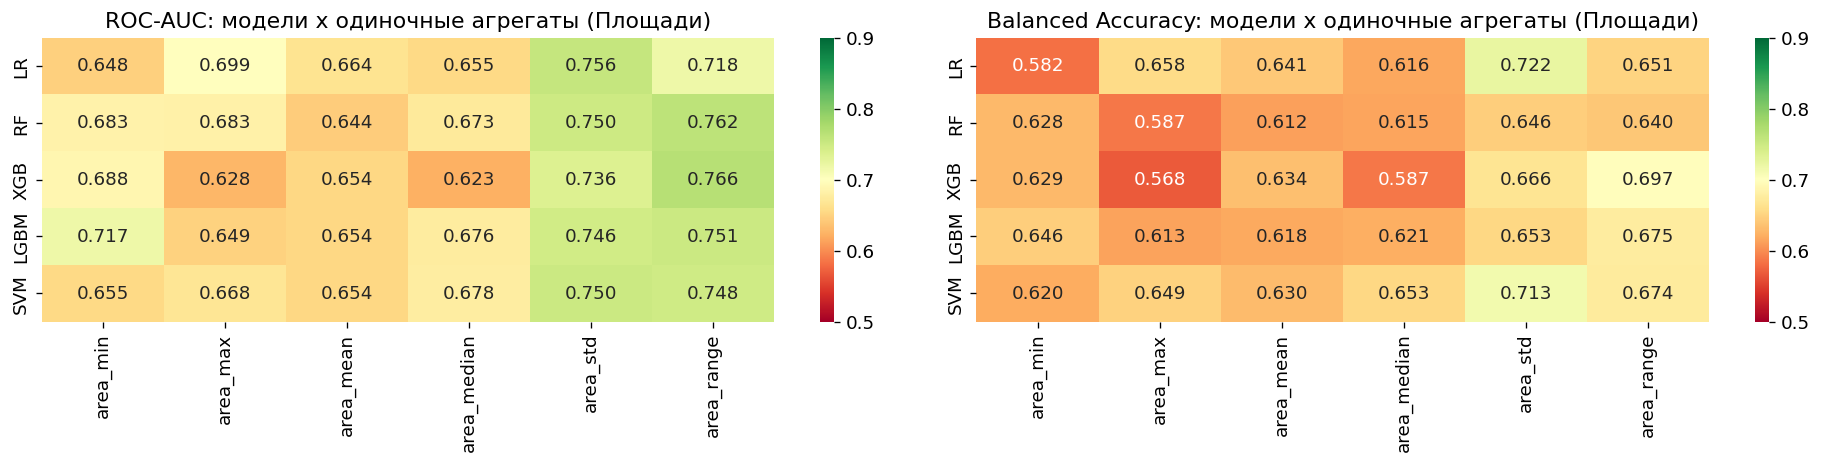

In [61]:
hm_auc_area = np.zeros((len(model_names), len(area_aggs)))
hm_bal_area = np.zeros((len(model_names), len(area_aggs)))
for i, mn in enumerate(model_names):
    for j, agg in enumerate(area_aggs):
        hm_auc_area[i, j] = area_single[agg]['res'][mn]['roc_auc']
        hm_bal_area[i, j] = area_single[agg]['res'][mn]['bal_acc']

fig, axes = plt.subplots(1, 2, figsize=(max(10, len(area_aggs)*2+4), 4))
sns.heatmap(hm_auc_area, xticklabels=area_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: модели x одиночные агрегаты (Площади)')
sns.heatmap(hm_bal_area, xticklabels=area_aggs, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: модели x одиночные агрегаты (Площади)')
plt.tight_layout(); plt.show()


### 8.2 Все комбинации агрегатов

Все непустые подмножества агрегатов группы. Для каждой комбинации — все пять моделей.


In [63]:
area_combos = dict(area_single)  # одиночные уже есть
for n_c in range(2, len(area_aggs) + 1):
    for combo in combinations(area_aggs, n_c):
        combo_name = '+'.join(combo)
        print(f'>>> {combo_name}')
        res, n_feat = run_area_models(list(combo))
        area_combos[combo_name] = {'res': res, 'n_feat': n_feat}
print(f'\nВсего комбинаций: {len(area_combos)}')


>>> area_min+area_max
>>> area_min+area_mean
>>> area_min+area_median
>>> area_min+area_std
>>> area_min+area_range
>>> area_max+area_mean
>>> area_max+area_median
>>> area_max+area_std
>>> area_max+area_range
>>> area_mean+area_median
>>> area_mean+area_std
>>> area_mean+area_range
>>> area_median+area_std
>>> area_median+area_range
>>> area_std+area_range
>>> area_min+area_max+area_mean
>>> area_min+area_max+area_median
>>> area_min+area_max+area_std
>>> area_min+area_max+area_range
>>> area_min+area_mean+area_median
>>> area_min+area_mean+area_std
>>> area_min+area_mean+area_range
>>> area_min+area_median+area_std
>>> area_min+area_median+area_range
>>> area_min+area_std+area_range
>>> area_max+area_mean+area_median
>>> area_max+area_mean+area_std
>>> area_max+area_mean+area_range
>>> area_max+area_median+area_std
>>> area_max+area_median+area_range
>>> area_max+area_std+area_range
>>> area_mean+area_median+area_std
>>> area_mean+area_median+area_range
>>> area_mean+area_std+area_ra

In [64]:
# Рейтинг комбинаций
combo_rows_area = []
for combo_name, data in area_combos.items():
    best_model = max(data['res'], key=lambda m: data['res'][m]['roc_auc'])
    best = data['res'][best_model]
    combo_rows_area.append({
        'Aggregates':  combo_name,
        'N_agg':       combo_name.count('+')+1,
        'Features':    data['n_feat'],
        'Best model':  best_model,
        'Bal.Acc':     best['bal_acc'],
        'F1':          best['f1'],
        'ROC-AUC':     best['roc_auc'],
        'Sens':        best['sens'],
        'Spec':        best['spec'],
    })
area_combo_df = (pd.DataFrame(combo_rows_area)
                         .sort_values('ROC-AUC', ascending=False)
                         .reset_index(drop=True))
print(f'Рейтинг комбинаций (Площади):')
display(area_combo_df.style.format(
    {'Bal.Acc':'{:.3f}','F1':'{:.3f}','ROC-AUC':'{:.3f}','Sens':'{:.3f}','Spec':'{:.3f}'}))


Рейтинг комбинаций (Площади):


,Aggregates,N_agg,Features,Best model,Bal.Acc,F1,ROC-AUC,Sens,Spec
0,area_min+area_range,2,113,LGBM,0.662,0.748,0.787,0.780,0.545
1,area_min+area_std+area_range,3,168,RF,0.670,0.779,0.784,0.855,0.484
2,area_mean+area_range,2,106,XGB,0.696,0.781,0.779,0.819,0.572
3,area_mean+area_median+area_range,3,108,LGBM,0.689,0.780,0.778,0.825,0.554
4,area_min+area_mean+area_median+area_range,4,167,LGBM,0.690,0.778,0.775,0.819,0.562
5,area_median+area_range,2,106,XGB,0.685,0.771,0.772,0.806,0.564
6,area_median+area_std,2,107,SVM,0.686,0.779,0.771,0.825,0.547
7,area_min+area_median+area_std+area_range,4,220,RF,0.635,0.768,0.769,0.850,0.421
8,area_min+area_mean+area_std+area_range,4,220,RF,0.660,0.781,0.769,0.862,0.457
9,area_min+area_max+area_median+area_std+area_range,5,263,RF,0.643,0.789,0.768,0.901,0.385


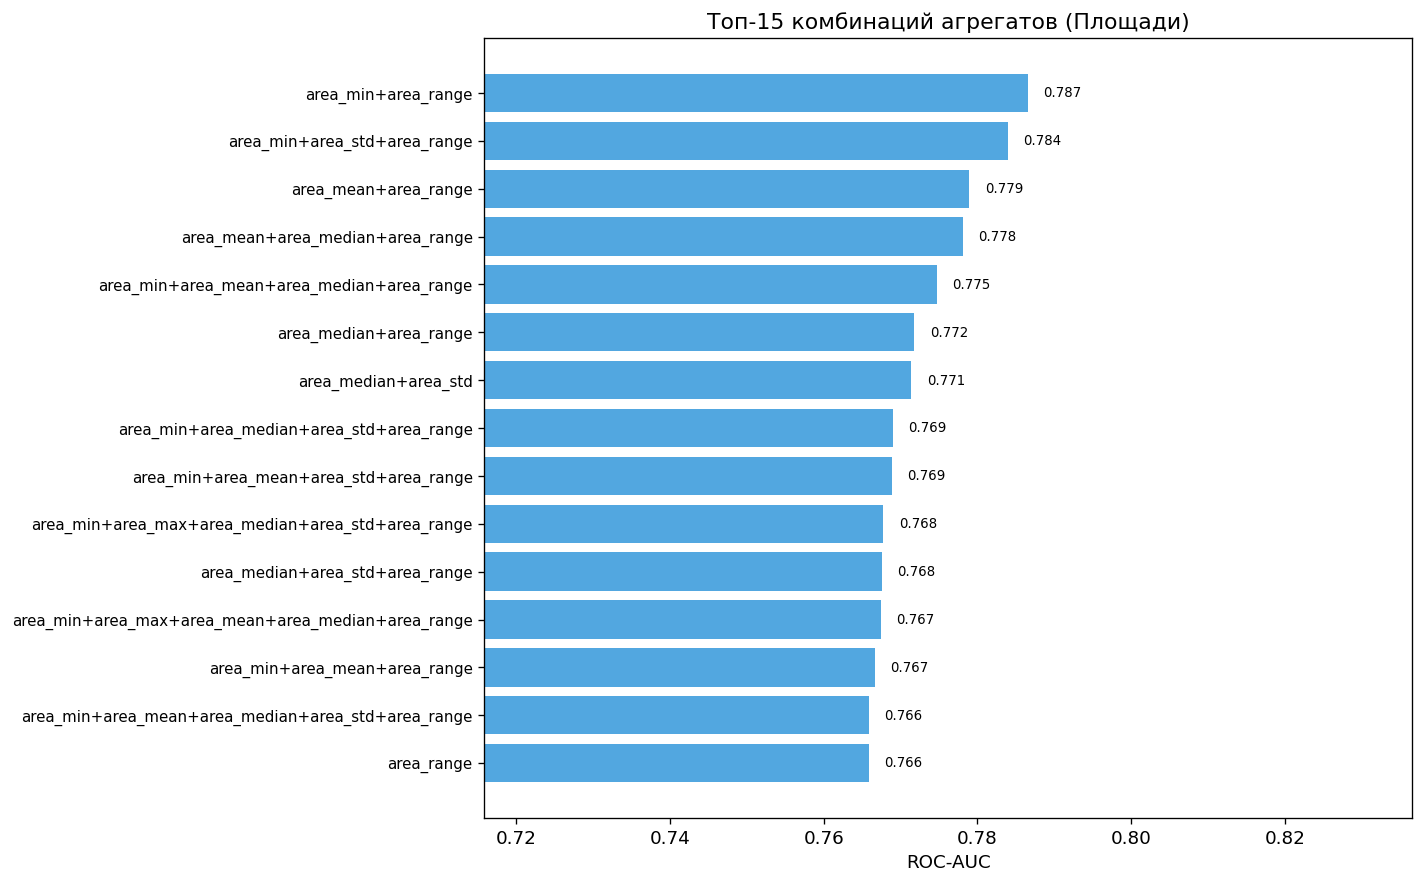

In [65]:
# Топ-15 комбинаций — barplot
top_n = min(15, len(area_combo_df))
top = area_combo_df.head(top_n)
fig, ax = plt.subplots(figsize=(12, max(5, top_n*0.5)))
ax.barh(range(len(top)), top['ROC-AUC'].values, color='#3498db', alpha=0.85)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['Aggregates'].values, fontsize=13)
ax.set_xlabel('ROC-AUC')
ax.set_title(f'Топ-{top_n} комбинаций агрегатов (Площади)')
ax.invert_yaxis()
ax.set_xlim(max(0.4, top['ROC-AUC'].min()-0.05), min(1.0, top['ROC-AUC'].max()+0.05))
for i, val in enumerate(top['ROC-AUC'].values):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


### 8.3 Детальная оценка лучшей комбинации (Площади)

In [67]:
area_best_name  = area_combo_df.iloc[0]['Aggregates']
area_best_model_name = area_combo_df.iloc[0]['Best model']
print(f'Лучшая комбинация: {area_best_name}')
print(f'Лучшая модель:     {area_best_model_name}')

area_best_list = area_best_name.split('+')
X_area, y_area, g_area = prepare_area_data(area_best_list)

cf_tmp = CorrelationFilter(0.95).fit(X_area)
print(f'Признаков до фильтра: {X_area.shape[1]}')
print(f'Признаков после фильтра: {cf_tmp.keep_mask_.sum()}')

cv_best = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model_map_area = _make_models(y_area.values)
best_m_area = model_map_area[area_best_model_name]

oof_preds_area = np.zeros(len(y_area))
oof_proba_area = np.zeros(len(y_area))
for tr, te in cv_best.split(X_area, y_area, g_area):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_m_area))])
    pipe.fit(X_area.iloc[tr], y_area.iloc[tr])
    oof_preds_area[te] = pipe.predict(X_area.iloc[te])
    oof_proba_area[te] = pipe.predict_proba(X_area.iloc[te])[:, 1]

print(classification_report(y_area, oof_preds_area, target_names=['Healthy','PD']))


Лучшая комбинация: area_min+area_range
Лучшая модель:     LGBM
Признаков до фильтра: 136
Признаков после фильтра: 112
              precision    recall  f1-score   support

     Healthy       0.60      0.52      0.55        99
          PD       0.72      0.78      0.75       156

    accuracy                           0.68       255
   macro avg       0.66      0.65      0.65       255
weighted avg       0.67      0.68      0.67       255



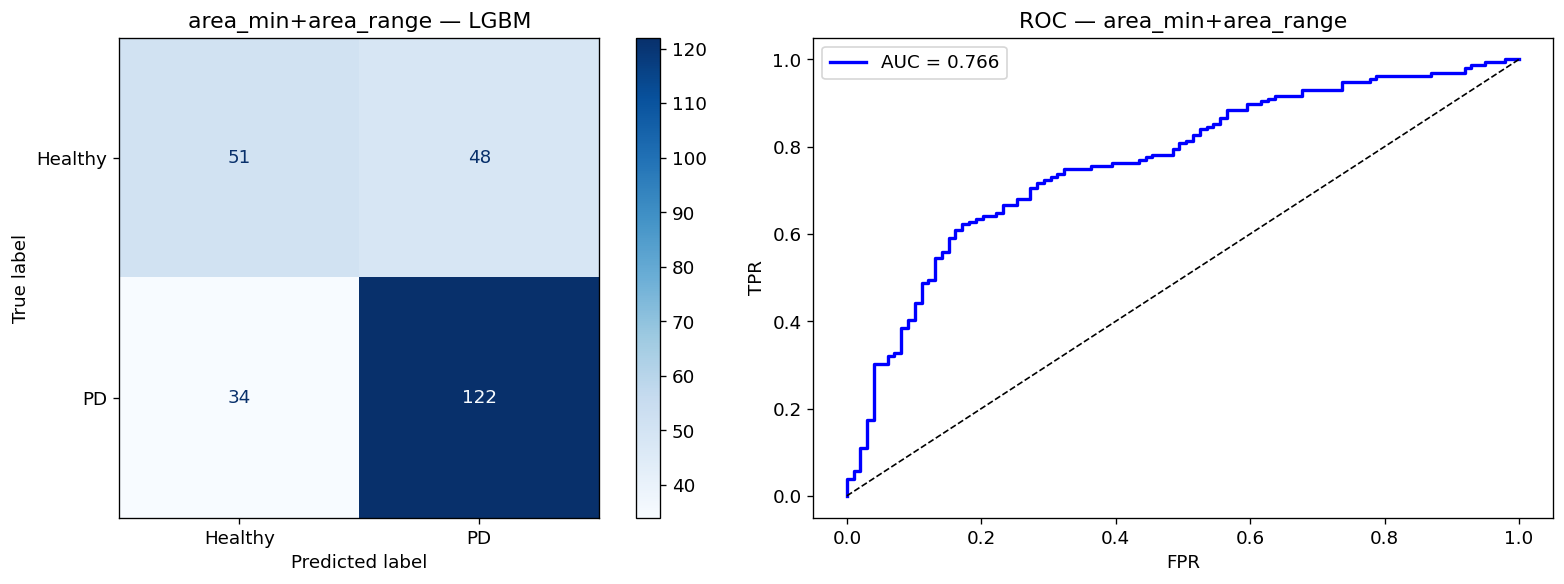

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_area, oof_preds_area)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{area_best_name} — {area_best_model_name}')

fpr, tpr, _ = roc_curve(y_area, oof_proba_area)
auc_val = roc_auc_score(y_area, oof_proba_area)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {area_best_name}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 9. Межгрупповое сравнение: лучшие агрегаты из каждой группы

Подход: взять лучший набор агрегатов из каждой группы (тот, что дал максимальный ROC-AUC внутри группы)
и объединить их в одну модель. Это позволяет проверить, не дублируют ли группы информацию —
и работает ли «коллективный разум» лучших агрегатов лучше, чем каждая группа по отдельности.

**Конфигурации для сравнения:**
- Индивидуальные лучшие (recap из разделов 5–8)
- Лучшая геом + лучшая дин (объединённый pivot)
- Лучшая геом + лучшая дин + лучшая углы
- Лучшая геом + лучшая дин + лучшая углы + лучшие площади (полная «сборная»)
- Все агрегаты всех dist_-групп (глобальный baseline)
- Все dist_ + все площади (максимальное пространство)


In [70]:
# Вспомогательная функция: объединить произвольные dist_-агрегаты + опциональные area-агрегаты
def prepare_combined(dist_agg_list, area_agg_list=None, include_duration=False):
    if len(dist_agg_list) == 1:
        sub = df[df['Aggregate'] == dist_agg_list[0]].copy()
        pivot = sub[['Patient','r','label',DURATION_COL] + list(dist_cols)].copy()
        feat = list(dist_cols)
    else:
        sub = df[df['Aggregate'].isin(dist_agg_list)]
        pivot = sub.pivot_table(index=['Patient','r','label',DURATION_COL],
                                columns='Aggregate', values=dist_cols, aggfunc='first')
        pivot.columns = [f'{f}_{a}' for f, a in pivot.columns]
        pivot = pivot.reset_index()
        feat = [c for c in pivot.columns if c.startswith('dist_')]

    if area_agg_list:
        area_feat = get_area_feat(area_agg_list)
        sub_area = df_wide[['id','r'] + area_feat].rename(columns={'id': 'Patient'})
        pivot = pivot.merge(sub_area, on=['Patient','r'], how='left')
        feat = feat + area_feat

    if include_duration:
        feat = feat + [DURATION_COL]

    return pivot[feat], pivot['label'], pivot['Patient']


# Recap: лучший набор агрегатов из каждой группы
print('Лучшие комбинации по группам:')
print(f'  Геометрия: {geom_best_list}  ({geom_best_name})')
print(f'  Динамика:  {dyn_best_list}  ({dyn_best_name})')
print(f'  Углы:      {ang_best_list}  ({ang_best_name})')
print(f'  Площади:   {area_best_list}  ({area_best_name})')


Лучшие комбинации по группам:
  Геометрия: ['min_norm', 'std_norm']  (min_norm+std_norm)
  Динамика:  ['max_vel_norm', 'mean_vel_norm', 'std_vel_norm']  (max_vel_norm+mean_vel_norm+std_vel_norm)
  Углы:      ['mean_angle', 'std_angle']  (mean_angle+std_angle)
  Площади:   ['area_min', 'area_range']  (area_min+area_range)


In [71]:
# Объединённые конфигурации из лучших агрегатов
best_geom_dyn      = list(dict.fromkeys(geom_best_list + dyn_best_list))
best_geom_dyn_ang  = list(dict.fromkeys(geom_best_list + dyn_best_list + ang_best_list))

cross_results = {
    'Геометрия (best)': geom_combos[geom_best_name]['res'],
    'Динамика (best)':  dyn_combos[dyn_best_name]['res'],
    'Углы (best)':      ang_combos[ang_best_name]['res'],
    'Площади (best)':   area_combos[area_best_name]['res'],
}

print('>>> Best Геом + Best Дин')
res, _ = run_models(best_geom_dyn)
cross_results['Best Геом + Best Дин'] = res

print('>>> Best Геом + Best Дин + Best Углы')
res, _ = run_models(best_geom_dyn_ang)
cross_results['Best Геом + Best Дин + Best Углы'] = res

print('>>> Best Геом + Best Дин + Best Углы + Best Площади  (полная сборная)')
X_best_all, y_best_all, g_best_all = prepare_combined(
    best_geom_dyn_ang, area_agg_list=area_best_list)
res, _ = run_models_xy(X_best_all, y_best_all, g_best_all)
cross_results['Best all groups'] = res

print('>>> Все dist_ агрегаты (13 типов)')
res, _ = run_models(ALL_DIST_AGGS)
cross_results['Все dist_ агрегаты'] = res

print('>>> Все dist_ + все площади')
X_all_full, y_all_full, g_all_full = prepare_combined(ALL_DIST_AGGS, area_agg_list=AREA_AGGS)
res, _ = run_models_xy(X_all_full, y_all_full, g_all_full)
cross_results['Все dist_ + все площади'] = res

print('Готово.')


>>> Best Геом + Best Дин
>>> Best Геом + Best Дин + Best Углы
>>> Best Геом + Best Дин + Best Углы + Best Площади  (полная сборная)
>>> Все dist_ агрегаты (13 типов)
>>> Все dist_ + все площади
Готово.


,Конфигурация,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,Best Геом + Best Дин + Best Углы,LGBM,0.9051,0.8260,0.9345,0.7175
1,Best all groups,LGBM,0.8974,0.7981,0.8765,0.7196
2,Best Геом + Best Дин,LGBM,0.8938,0.8081,0.8776,0.7386
3,Динамика (best),LR,0.8910,0.8252,0.8314,0.8189
4,Все dist_ агрегаты,LGBM,0.8839,0.7709,0.8776,0.6642
5,Все dist_ + все площади,XGB,0.8837,0.8069,0.8504,0.7634
6,Геометрия (best),SVM,0.7980,0.7239,0.7728,0.6749
7,Площади (best),LGBM,0.7866,0.6622,0.7798,0.5446
8,Углы (best),LR,0.7012,0.6513,0.7744,0.5281


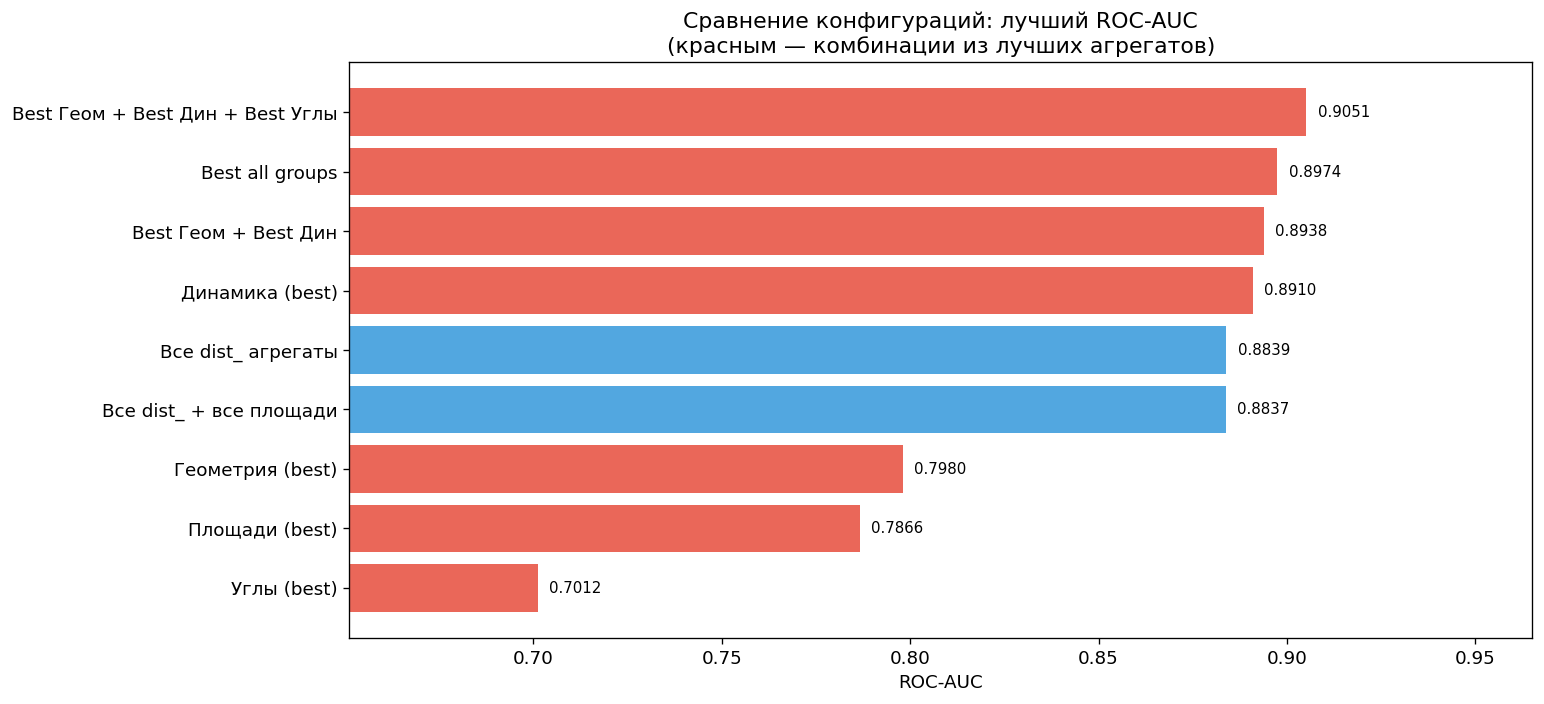

In [72]:
# Сводная таблица
cross_rows = []
for lbl, res in cross_results.items():
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    cross_rows.append({
        'Конфигурация':  lbl,
        'Лучшая модель': best_m,
        'ROC-AUC':       round(res[best_m]['roc_auc'], 4),
        'Bal.Acc':       round(res[best_m]['bal_acc'], 4),
        'Sens':          round(res[best_m]['sens'], 4),
        'Spec':          round(res[best_m]['spec'], 4),
    })
cross_df = (pd.DataFrame(cross_rows)
            .sort_values('ROC-AUC', ascending=False)
            .reset_index(drop=True))

display(cross_df.style.format(
    {'ROC-AUC':'{:.4f}','Bal.Acc':'{:.4f}','Sens':'{:.4f}','Spec':'{:.4f}'}))

# Barplot
colors_bar = ['#e74c3c' if 'Best all' in lbl or 'best' in lbl.lower() else '#3498db'
              for lbl in cross_df['Конфигурация']]
fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(cross_df['Конфигурация'][::-1], cross_df['ROC-AUC'][::-1],
        color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('ROC-AUC')
ax.set_title('Сравнение конфигураций: лучший ROC-AUC\n(красным — комбинации из лучших агрегатов)')
xleft = max(0.4, cross_df['ROC-AUC'].min() - 0.05)
ax.set_xlim(xleft, min(1.0, cross_df['ROC-AUC'].max() + 0.06))
for i, (lbl, val) in enumerate(zip(cross_df['Конфигурация'][::-1], cross_df['ROC-AUC'][::-1])):
    ax.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=13)
plt.tight_layout(); plt.show()


## 10. Влияние клинического параметра `exercise_duration`

Сравниваем все конфигурации с добавлением `exercise_duration` — времени выполнения упражнения (прокси брадикинезии).


In [74]:
dur_configs_dist = {
    'Геометрия':     GEOM_AGGS,
    'Динамика':      DYN_AGGS,
    'Углы':          ANG_AGGS,
    'Геом+Дин':      GEOM_AGGS + DYN_AGGS,
    'Геом+Дин+Углы': ALL_DIST_AGGS,
}

dur_rows = []
for lbl, agg_list in dur_configs_dist.items():
    res_no, _  = run_models(agg_list, include_duration=False)
    res_ex, _  = run_models(agg_list, include_duration=True)
    best_no = max(res_no, key=lambda m: res_no[m]['roc_auc'])
    best_ex = max(res_ex, key=lambda m: res_ex[m]['roc_auc'])
    auc_no = res_no[best_no]['roc_auc']
    auc_ex = res_ex[best_ex]['roc_auc']
    dur_rows.append({
        'Конфигурация': lbl,
        'AUC без ex_dur': f'{auc_no:.3f} ({best_no})',
        'AUC с ex_dur':   f'{auc_ex:.3f} ({best_ex})',
        'Delta AUC':      f'{auc_ex - auc_no:+.3f}',
        'BAcc без':        f'{res_no[best_no]["bal_acc"]:.3f}',
        'BAcc с':          f'{res_ex[best_ex]["bal_acc"]:.3f}',
    })
    print(f'{lbl}: AUC без={auc_no:.3f}, с={auc_ex:.3f}, delta={auc_ex-auc_no:+.3f}')

print('>>> Площади с ex_duration')
res_area_no, _ = run_area_models(AREA_AGGS, include_duration=False)
res_area_ex, _ = run_area_models(AREA_AGGS, include_duration=True)
# Независимый выбор лучшей модели для каждой конфигурации
best_ae_no = max(res_area_no, key=lambda m: res_area_no[m]['roc_auc'])
best_ae_ex = max(res_area_ex, key=lambda m: res_area_ex[m]['roc_auc'])
auc_ae_no = res_area_no[best_ae_no]['roc_auc']
auc_ae_ex = res_area_ex[best_ae_ex]['roc_auc']
dur_rows.append({
    'Конфигурация': 'Площади',
    'AUC без ex_dur': f'{auc_ae_no:.3f} ({best_ae_no})',
    'AUC с ex_dur':   f'{auc_ae_ex:.3f} ({best_ae_ex})',
    'Delta AUC':      f'{auc_ae_ex - auc_ae_no:+.3f}',
    'BAcc без':        f'{res_area_no[best_ae_no]["bal_acc"]:.3f}',
    'BAcc с':          f'{res_area_ex[best_ae_ex]["bal_acc"]:.3f}',
})

display(pd.DataFrame(dur_rows).set_index('Конфигурация'))


Геометрия: AUC без=0.747, с=0.870, delta=+0.123
Динамика: AUC без=0.858, с=0.858, delta=+0.000
Углы: AUC без=0.694, с=0.828, delta=+0.134
Геом+Дин: AUC без=0.891, с=0.882, delta=-0.009
Геом+Дин+Углы: AUC без=0.884, с=0.878, delta=-0.006
>>> Площади с ex_duration


,AUC без ex_dur,AUC с ex_dur,Delta AUC,BAcc без,BAcc с
Конфигурация,,,,,
Геометрия,0.747 (RF),0.870 (XGB),+0.123,0.621,0.775
Динамика,0.858 (RF),0.858 (RF),+0.000,0.755,0.773
Углы,0.694 (LR),0.828 (XGB),+0.134,0.649,0.747
Геом+Дин,0.891 (LGBM),0.882 (LGBM),-0.009,0.811,0.795
Геом+Дин+Углы,0.884 (LGBM),0.878 (LGBM),-0.006,0.771,0.775
Площади,0.759 (RF),0.848 (XGB),+0.089,0.645,0.764


## 11. Сводка Block 2 и ROC-кривые лучшей конфигурации

In [76]:
# Сводная таблица: все конфигурации
all_bl2 = dict(cross_results)
all_bl2_labels = list(all_bl2.keys())

summary_bl2 = []
for lbl in all_bl2_labels:
    res = all_bl2[lbl]
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    summary_bl2.append({
        'Конфигурация':  lbl,
        'Лучшая модель': best_m,
        'ROC-AUC':       round(res[best_m]['roc_auc'], 4),
        'Bal.Acc':       round(res[best_m]['bal_acc'], 4),
        'Sens':          round(res[best_m]['sens'], 4),
        'Spec':          round(res[best_m]['spec'], 4),
    })
df_summary_bl2 = (pd.DataFrame(summary_bl2)
                  .sort_values('ROC-AUC', ascending=False)
                  .reset_index(drop=True))
display(df_summary_bl2.style.format(
    {'ROC-AUC':'{:.4f}','Bal.Acc':'{:.4f}','Sens':'{:.4f}','Spec':'{:.4f}'}))

# Определяем лучшую конфигурацию для Block 3
bl2_best_label = df_summary_bl2.iloc[0]['Конфигурация']
print(f'\nЛучшая конфигурация Block 2: {bl2_best_label}  '
      f'(ROC-AUC = {df_summary_bl2.iloc[0]["ROC-AUC"]:.4f})')


,Конфигурация,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,Best Геом + Best Дин + Best Углы,LGBM,0.9051,0.8260,0.9345,0.7175
1,Best all groups,LGBM,0.8974,0.7981,0.8765,0.7196
2,Best Геом + Best Дин,LGBM,0.8938,0.8081,0.8776,0.7386
3,Динамика (best),LR,0.8910,0.8252,0.8314,0.8189
4,Все dist_ агрегаты,LGBM,0.8839,0.7709,0.8776,0.6642
5,Все dist_ + все площади,XGB,0.8837,0.8069,0.8504,0.7634
6,Геометрия (best),SVM,0.7980,0.7239,0.7728,0.6749
7,Площади (best),LGBM,0.7866,0.6622,0.7798,0.5446
8,Углы (best),LR,0.7012,0.6513,0.7744,0.5281



Лучшая конфигурация Block 2: Best Геом + Best Дин + Best Углы  (ROC-AUC = 0.9051)


In [77]:
# Определяем X_best, y_best, groups_best для Block 3
bl2_best_label = df_summary_bl2.iloc[0]['Конфигурация']
print(f'Лучшая конфигурация Block 2: {bl2_best_label}')

_label_to_dist_agg = {
    'Геометрия (best)':              geom_best_list,
    'Динамика (best)':               dyn_best_list,
    'Углы (best)':                   ang_best_list,
    'Best Геом + Best Дин':          best_geom_dyn,
    'Best Геом + Best Дин + Best Углы': best_geom_dyn_ang,
    'Все dist_ агрегаты':            ALL_DIST_AGGS,
}

if bl2_best_label == 'Площади (best)':
    X_best, y_best, groups_best = prepare_area_data(area_best_list)
    _is_area_best = True
elif bl2_best_label == 'Best all groups':
    X_best, y_best, groups_best = X_best_all, y_best_all, g_best_all
    _is_area_best = False
elif bl2_best_label == 'Все dist_ + все площади':
    X_best, y_best, groups_best = X_all_full, y_all_full, g_all_full
    _is_area_best = False
else:
    agg_list_best = _label_to_dist_agg.get(bl2_best_label, ALL_DIST_AGGS)
    X_best, y_best, groups_best = prepare_data(agg_list_best)
    _is_area_best = False

best_res_bl2 = cross_results[bl2_best_label]
print(f'X_best: {X_best.shape}')


Лучшая конфигурация Block 2: Best Геом + Best Дин + Best Углы
X_best: (255, 434)


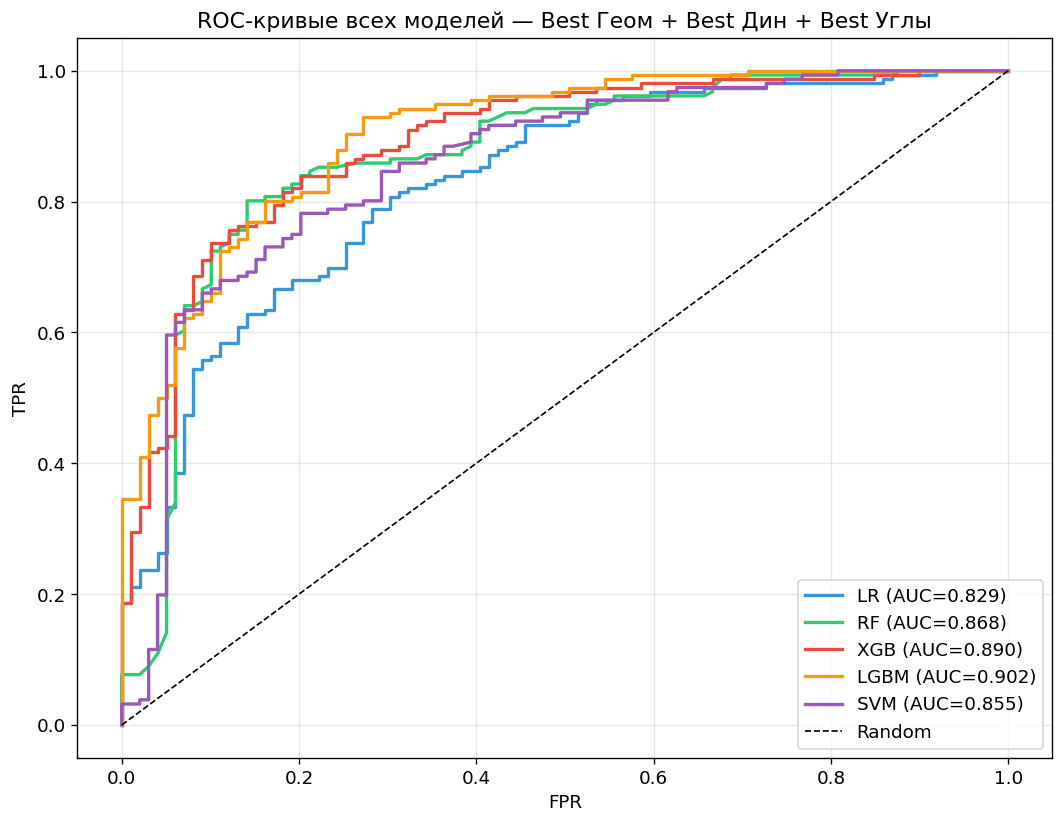

In [78]:
# ROC-кривые всех моделей для лучшей конфигурации
colors_m = {'LR':'#3498db','RF':'#2ecc71','XGB':'#e74c3c','LGBM':'#f39c12','SVM':'#9b59b6'}
cv_roc = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 7))
for mn, model in _make_models(y_best.values).items():
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', model)])
    oof_pr = np.zeros(len(y_best))
    for tr, te in cv_roc.split(X_best, y_best, groups_best):
        pipe_c = clone(pipe)
        pipe_c.fit(X_best.iloc[tr], y_best.iloc[tr])
        oof_pr[te] = pipe_c.predict_proba(X_best.iloc[te])[:, 1]
    fpr, tpr, _ = roc_curve(y_best, oof_pr)
    auc_m = roc_auc_score(y_best, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[mn], lw=2, label=f'{mn} (AUC={auc_m:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые всех моделей — {bl2_best_label}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---

# Block 3. Детальный анализ лучшей конфигурации

Все эксперименты выполняются на конфигурации, определённой автоматически по Block 2.


## 12. Детальная оценка лучшей конфигурации

In [81]:
print(f'Конфигурация: {bl2_best_label}')
print(f'X_best: {X_best.shape}')
print(f'PD={y_best.sum()}, Healthy={(y_best==0).sum()}')

best_model_name_bl3 = max(model_names, key=lambda m: best_res_bl2[m]['roc_auc'])
best_model_bl3 = _make_models(y_best.values)[best_model_name_bl3]
cv_det = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_preds_bl3 = np.zeros(len(y_best))
oof_proba_bl3 = np.zeros(len(y_best))
for tr, te in cv_det.split(X_best, y_best, groups_best):
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', clone(best_model_bl3))])
    pipe.fit(X_best.iloc[tr], y_best.iloc[tr])
    oof_preds_bl3[te] = pipe.predict(X_best.iloc[te])
    oof_proba_bl3[te] = pipe.predict_proba(X_best.iloc[te])[:, 1]

print(classification_report(y_best, oof_preds_bl3, target_names=['Healthy','PD']))


Конфигурация: Best Геом + Best Дин + Best Углы
X_best: (255, 434)
PD=156, Healthy=99
              precision    recall  f1-score   support

     Healthy       0.87      0.70      0.78        99
          PD       0.83      0.94      0.88       156

    accuracy                           0.84       255
   macro avg       0.85      0.82      0.83       255
weighted avg       0.85      0.84      0.84       255



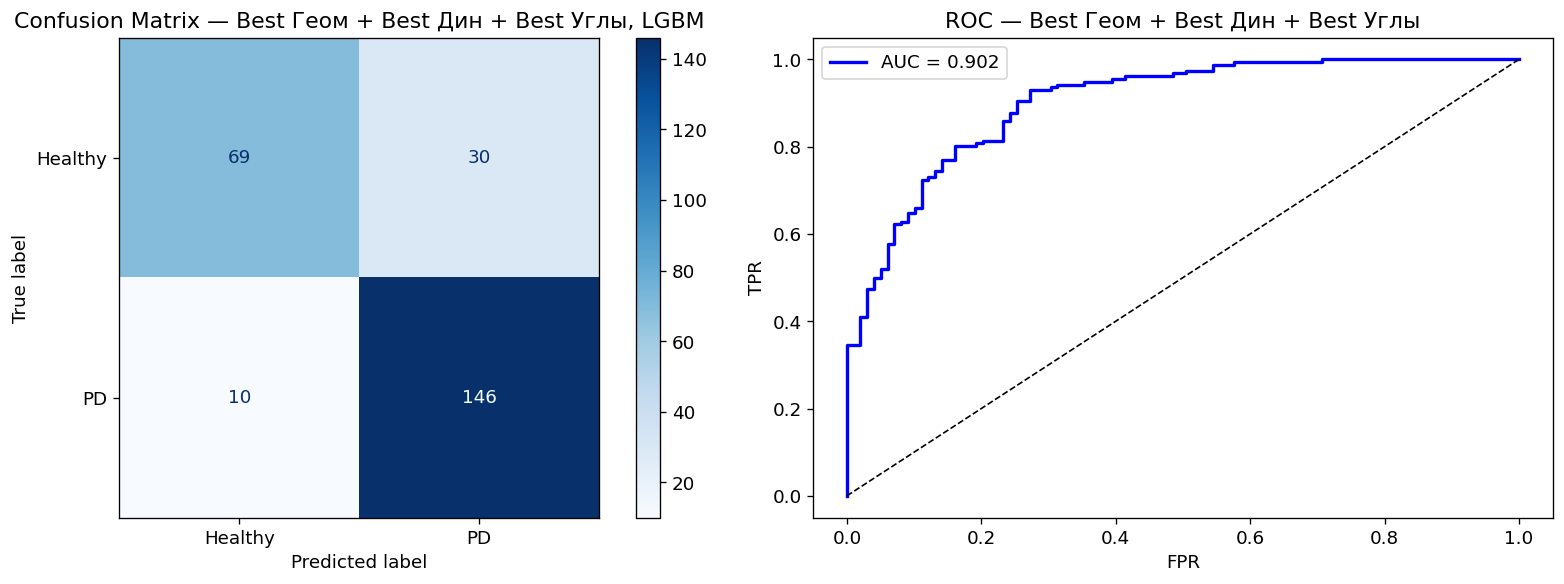

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_best, oof_preds_bl3)
ConfusionMatrixDisplay(cm, display_labels=['Healthy','PD']).plot(
    ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Confusion Matrix — {bl2_best_label}, {best_model_name_bl3}')

fpr_b3, tpr_b3, _ = roc_curve(y_best, oof_proba_bl3)
auc_b3 = roc_auc_score(y_best, oof_proba_bl3)
axes[1].plot(fpr_b3, tpr_b3, 'b-', lw=2, label=f'AUC = {auc_b3:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC — {bl2_best_label}'); axes[1].legend()
plt.tight_layout(); plt.show()


## 13. ROC-кривые всех моделей

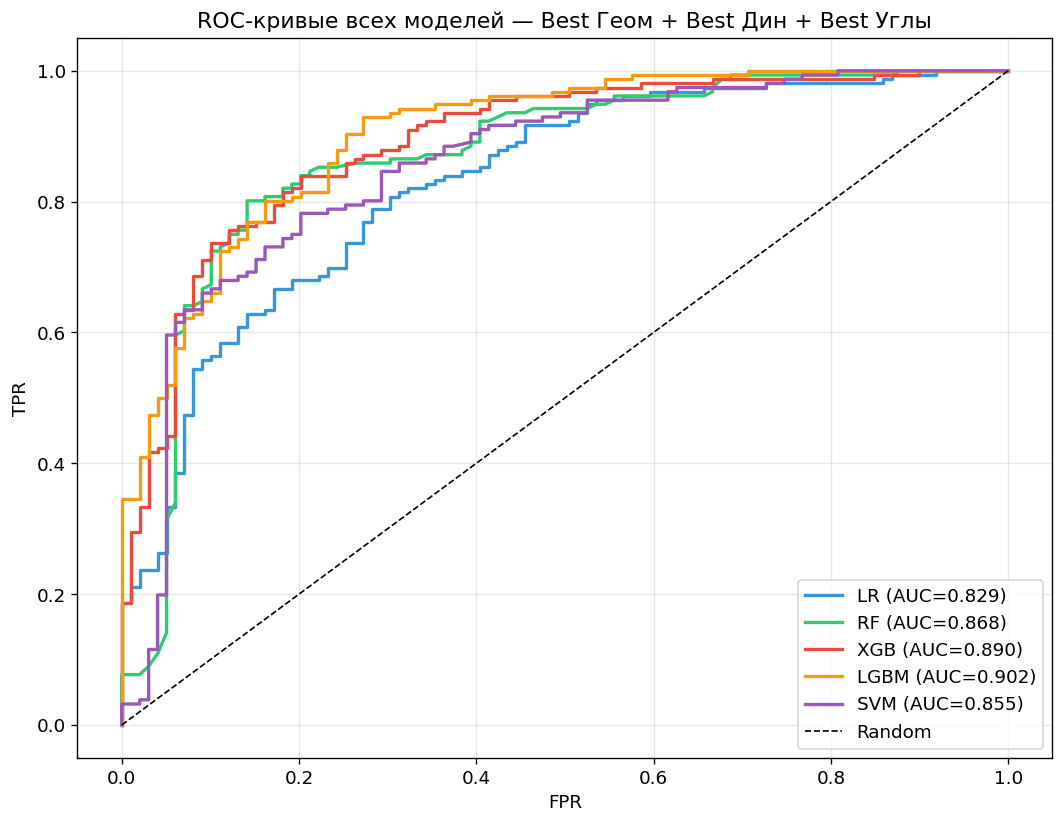

In [84]:
fig, ax = plt.subplots(figsize=(9, 7))
for mn, model in _make_models(y_best.values).items():
    pipe = Pipeline([('corr', CorrelationFilter(0.95)),
                     ('scaler', StandardScaler()),
                     ('model', model)])
    oof_pr = np.zeros(len(y_best))
    for tr, te in cv_roc.split(X_best, y_best, groups_best):
        pipe_c = clone(pipe)
        pipe_c.fit(X_best.iloc[tr], y_best.iloc[tr])
        oof_pr[te] = pipe_c.predict_proba(X_best.iloc[te])[:, 1]
    fpr, tpr, _ = roc_curve(y_best, oof_pr)
    ax.plot(fpr, tpr, color=colors_m[mn], lw=2,
            label=f'{mn} (AUC={roc_auc_score(y_best, oof_pr):.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC-кривые всех моделей — {bl2_best_label}')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 14. Feature importance

Признаков после фильтра: 156


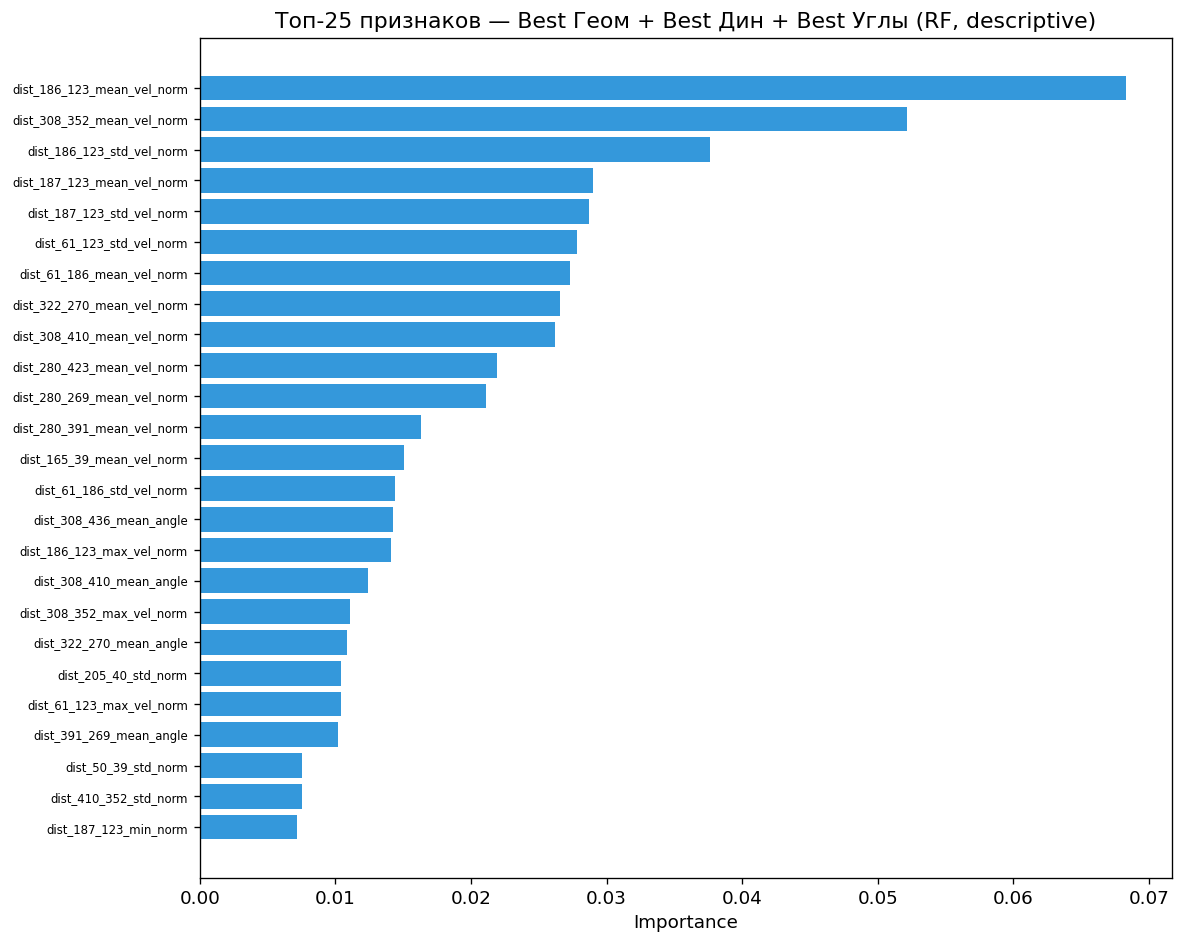

,feature,importance
0,dist_186_123_mean_vel_norm,0.068313
1,dist_308_352_mean_vel_norm,0.052151
2,dist_186_123_std_vel_norm,0.037634
3,dist_187_123_mean_vel_norm,0.029017
4,dist_187_123_std_vel_norm,0.028726
5,dist_61_123_std_vel_norm,0.027824
6,dist_61_186_mean_vel_norm,0.027343
7,dist_322_270_mean_vel_norm,0.026563
8,dist_308_410_mean_vel_norm,0.026168
9,dist_280_423_mean_vel_norm,0.021932


In [86]:
cf_fi = CorrelationFilter(0.95).fit(X_best)
X_best_f = X_best.iloc[:, np.where(cf_fi.keep_mask_)[0]]
filtered_names = X_best_f.columns.tolist()
print(f'Признаков после фильтра: {len(filtered_names)}')

rf_imp = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_imp.fit(StandardScaler().fit_transform(X_best_f), y_best)

imp = pd.DataFrame({'feature': filtered_names, 'importance': rf_imp.feature_importances_})
imp = imp.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(imp)), imp['importance'].values, color='#3498db')
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp['feature'].values, fontsize=13)
ax.set_xlabel('Importance')
ax.set_title(f'Топ-25 признаков — {bl2_best_label} (RF, descriptive)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()
display(imp.reset_index(drop=True))


## 15. UMAP — визуализация и препроцессинг

### 15.1 2D-визуализация


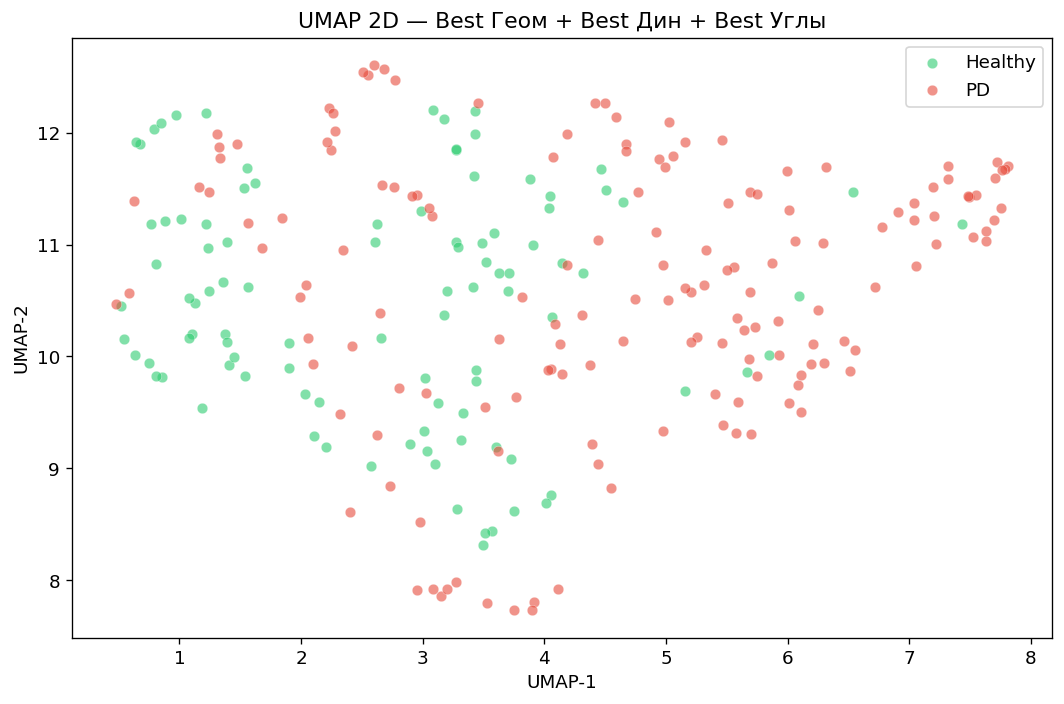

In [88]:
X_sc_umap = StandardScaler().fit_transform(X_best_f)
X_2d = UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=15).fit_transform(X_sc_umap)

fig, ax = plt.subplots(figsize=(9, 6))
for lv, ln, lc in [(0,'Healthy','#2ecc71'),(1,'PD','#e74c3c')]:
    mask = y_best.values == lv
    ax.scatter(X_2d[mask,0], X_2d[mask,1], c=lc, label=ln, alpha=0.6, s=40, edgecolors='white', linewidth=0.3)
ax.set_title(f'UMAP 2D — {bl2_best_label}')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2'); ax.legend()
plt.tight_layout(); plt.show()


### 15.2 UMAP как препроцессинг

In [90]:
n_components_list = [5, 10, 20]

def run_with_umap(X, y, groups, n_components):
    cv_u = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res_u = {}
    for name, model in _make_models(y.values).items():
        pipe_u = Pipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('umap',   UMAP(n_components=n_components, random_state=RANDOM_STATE, n_neighbors=15)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe_u, X, y, groups=groups, cv=cv_u,
                             scoring=scoring, return_train_score=False)
        res_u[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res_u

umap_results = {}
for nc in n_components_list:
    print(f'>>> UMAP n_components={nc}')
    umap_results[nc] = run_with_umap(X_best, y_best, groups_best, nc)


>>> UMAP n_components=5
>>> UMAP n_components=10
>>> UMAP n_components=20


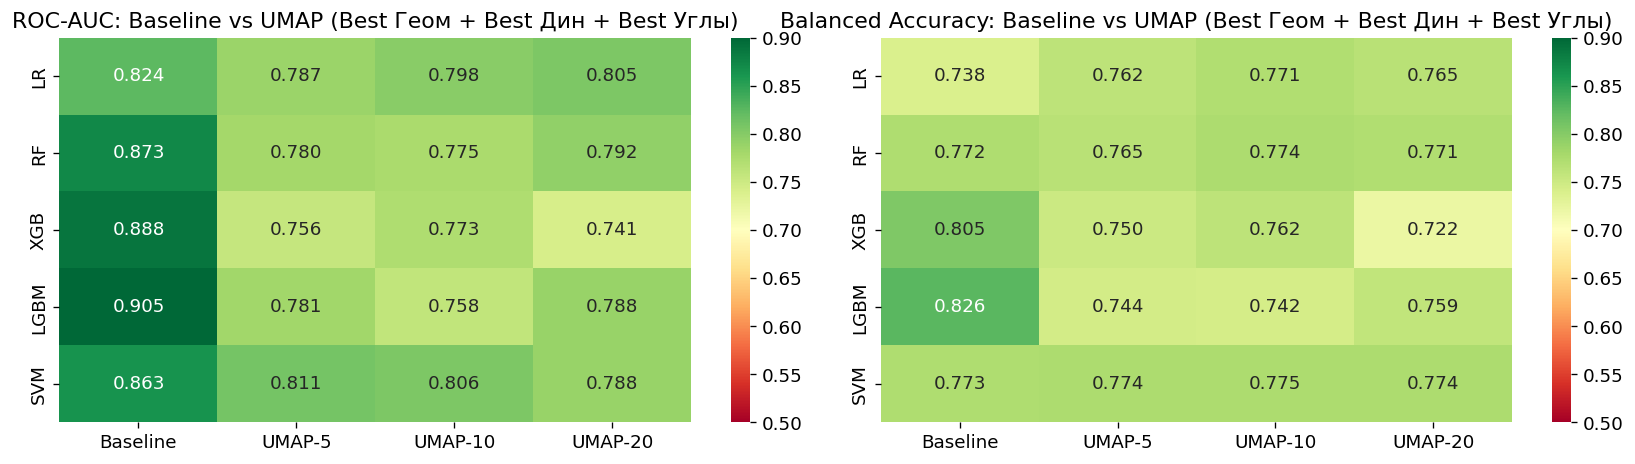

Лучший UMAP: n_components=5, AUC=0.811


In [91]:
col_labels = ['Baseline'] + [f'UMAP-{nc}' for nc in n_components_list]
hm_auc_u = np.zeros((len(model_names), len(col_labels)))
hm_bac_u = np.zeros((len(model_names), len(col_labels)))
for i, mn in enumerate(model_names):
    hm_auc_u[i, 0] = best_res_bl2[mn]['roc_auc']
    hm_bac_u[i, 0] = best_res_bl2[mn]['bal_acc']
    for j, nc in enumerate(n_components_list):
        hm_auc_u[i, j+1] = umap_results[nc][mn]['roc_auc'][0]
        hm_bac_u[i, j+1] = umap_results[nc][mn]['balanced_accuracy'][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_auc_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: Baseline vs UMAP ({bl2_best_label})')
sns.heatmap(hm_bac_u, xticklabels=col_labels, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: Baseline vs UMAP ({bl2_best_label})')
plt.tight_layout(); plt.show()

best_nc = max(n_components_list,
              key=lambda nc: max(umap_results[nc][m]['roc_auc'][0] for m in model_names))
best_umap_auc = max(umap_results[best_nc][m]['roc_auc'][0] for m in model_names)
print(f'Лучший UMAP: n_components={best_nc}, AUC={best_umap_auc:.3f}')


## 16. SMOTE — балансировка классов

In [93]:
def run_with_smote(X, y, groups, k_neighbors=5):
    cv_s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res_s = {}
    for name, model in _make_models(y.values).items():
        pipe_s = ImbPipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('smote',  SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)),
            ('model',  model),
        ])
        cvr = cross_validate(pipe_s, X, y, groups=groups, cv=cv_s,
                             scoring=scoring, return_train_score=False)
        res_s[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res_s

smote_results = {}
for k in [3, 5]:
    print(f'>>> SMOTE k={k}')
    smote_results[k] = run_with_smote(X_best, y_best, groups_best, k)


>>> SMOTE k=3
>>> SMOTE k=5


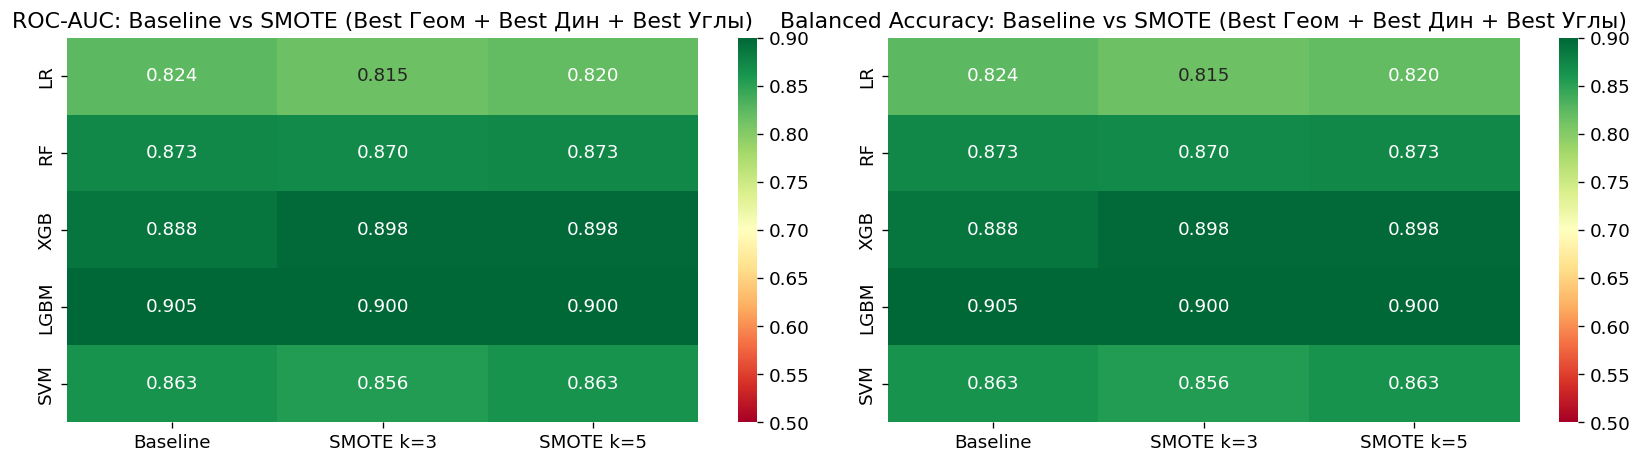

Лучший SMOTE AUC: 0.900


In [94]:
cols_smote = ['Baseline', 'SMOTE k=3', 'SMOTE k=5']
hm_s = np.zeros((len(model_names), 3))
for i, mn in enumerate(model_names):
    hm_s[i, 0] = best_res_bl2[mn]['roc_auc']
    hm_s[i, 1] = smote_results[3][mn]['roc_auc'][0]
    hm_s[i, 2] = smote_results[5][mn]['roc_auc'][0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(hm_s, xticklabels=cols_smote, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[0])
axes[0].set_title(f'ROC-AUC: Baseline vs SMOTE ({bl2_best_label})')
sns.heatmap(hm_s, xticklabels=cols_smote, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=axes[1])
axes[1].set_title(f'Balanced Accuracy: Baseline vs SMOTE ({bl2_best_label})')
plt.tight_layout(); plt.show()

best_smote_auc = max(smote_results[k][m]['roc_auc'][0] for k in [3,5] for m in model_names)
print(f'Лучший SMOTE AUC: {best_smote_auc:.3f}')


## 17. Влияние `exercise_duration` на лучшую конфигурацию

In [96]:
if not _is_area_best and bl2_best_label != 'Геом+Площади':
    _agg_map = {
        'Геометрия': GEOM_AGGS, 'Динамика': DYN_AGGS, 'Углы': ANG_AGGS,
        'Геом+Дин': GEOM_AGGS+DYN_AGGS, 'Геом+Дин+Углы': ALL_DIST_AGGS,
    }
    _best_agg_list = _agg_map.get(bl2_best_label, ALL_DIST_AGGS)
    res_no_dur, _ = run_models(_best_agg_list, include_duration=False)
    res_ex_dur, _ = run_models(_best_agg_list, include_duration=True)
else:
    res_no_dur = best_res_bl2
    res_ex_dur, _ = run_area_models(AREA_AGGS, include_duration=True)

dur_cmp_rows = []
for mn in model_names:
    dur_cmp_rows.append({
        'Модель':        mn,
        'AUC без ex_dur': round(res_no_dur[mn]['roc_auc'], 4),
        'AUC с ex_dur':   round(res_ex_dur[mn]['roc_auc'][0] if isinstance(res_ex_dur[mn]['roc_auc'], tuple)
                                else res_ex_dur[mn]['roc_auc'], 4),
        'Delta':          round((res_ex_dur[mn]['roc_auc'][0] if isinstance(res_ex_dur[mn]['roc_auc'], tuple)
                                 else res_ex_dur[mn]['roc_auc']) - res_no_dur[mn]['roc_auc'], 4),
    })
display(pd.DataFrame(dur_cmp_rows))


,Модель,AUC без ex_dur,AUC с ex_dur,Delta
0,LR,0.8145,0.8257,0.0111
1,RF,0.8642,0.8606,-0.0036
2,XGB,0.8776,0.8693,-0.0083
3,LGBM,0.8839,0.8783,-0.0056
4,SVM,0.8471,0.8518,0.0047


## 18. Отбор признаков по направлению движения

Применяем `DirectionalFeatureSelector` к конфигурации с геометрическими агрегатами (содержат min/max).
Проверяется гипотеза: часть min/max признаков является шумом — расстояние движется в противоположном направлении.


In [98]:
def compute_directions(df_ref, eps=0.02, healthy_only=True):
    df_r = df_ref[df_ref['label'] == 0] if healthy_only else df_ref
    mean_rows = df_r[df_r['Aggregate'] == 'mean_norm']
    directions = {}
    for c in dist_cols:
        m = mean_rows[c].mean()
        if m > 1 + eps: directions[c] = 'expand'
        elif m < 1 - eps: directions[c] = 'contract'
        else: directions[c] = 'neutral'
    return directions

directions = compute_directions(df, eps=0.02, healthy_only=True)
exp = sum(1 for v in directions.values() if v == 'expand')
con = sum(1 for v in directions.values() if v == 'contract')
neu = sum(1 for v in directions.values() if v == 'neutral')
print(f'Расширяются (max информативен): {exp}')
print(f'Сжимаются   (min информативен): {con}')
print(f'Нейтральные:                   {neu}')


Расширяются (max информативен): 4
Сжимаются   (min информативен): 54
Нейтральные:                   4


In [99]:
def prepare_data_dir(agg_list, mode='baseline', directions=None):
    if len(agg_list) == 1:
        sub = df[df['Aggregate'] == agg_list[0]].copy()
        feat = list(dist_cols)
        if mode == 'directional':
            if agg_list[0] == 'max_norm':
                feat = [c for c in feat if directions.get(c) == 'expand']
            elif agg_list[0] == 'min_norm':
                feat = [c for c in feat if directions.get(c) == 'contract']
        return sub[feat], sub['label'], sub['Patient']
    sub = df[df['Aggregate'].isin(agg_list)]
    pivot = sub.pivot_table(index=['Patient','r','label'], columns='Aggregate', values=dist_cols)
    pivot.columns = [f'{f}_{a}' for f, a in pivot.columns]
    pivot = pivot.reset_index()
    feat = [c for c in pivot.columns if c.startswith('dist_')]
    if mode == 'directional':
        new_feat = []
        for col in feat:
            if col.endswith('_max_norm'):
                if directions.get(col.replace('_max_norm','')) == 'expand': new_feat.append(col)
            elif col.endswith('_min_norm'):
                if directions.get(col.replace('_min_norm','')) == 'contract': new_feat.append(col)
            else:
                new_feat.append(col)
        feat = new_feat
    elif mode == 'minimal':
        feat = [c for c in feat if not (c.endswith('_max_norm') or c.endswith('_min_norm'))]
    return pivot[feat], pivot['label'], pivot['Patient']


def run_dir_experiment(agg_list, mode, directions=None):
    X, y, groups = prepare_data_dir(agg_list, mode=mode, directions=directions)
    res, nf = run_models_xy(X, y, groups)
    return res, X.shape[1]

dir_experiments = [
    ('Геом baseline',    GEOM_AGGS, 'baseline'),
    ('Геом directional', GEOM_AGGS, 'directional'),
    ('Геом minimal',     GEOM_AGGS, 'minimal'),
]

dir_results = {}
for label, agg_list, mode in dir_experiments:
    print(f'>>> {label}')
    res, nf = run_dir_experiment(agg_list, mode, directions)
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    dir_results[label] = {'res': res, 'nf': nf}
    print(f'    Признаков={nf}, AUC={res[best_m]["roc_auc"]:.3f} ({best_m})')


>>> Геом baseline
    Признаков=310, AUC=0.747 (RF)
>>> Геом directional
    Признаков=244, AUC=0.747 (LGBM)
>>> Геом minimal
    Признаков=186, AUC=0.754 (RF)


,Конфигурация,Признаков,Лучшая модель,ROC-AUC,Bal.Acc,Sens,Spec
0,Геом baseline,310,RF,0.7471,0.6207,0.8750,0.3663
1,Геом directional,244,LGBM,0.7473,0.6727,0.8244,0.5210
2,Геом minimal,186,RF,0.7539,0.6161,0.8302,0.4020


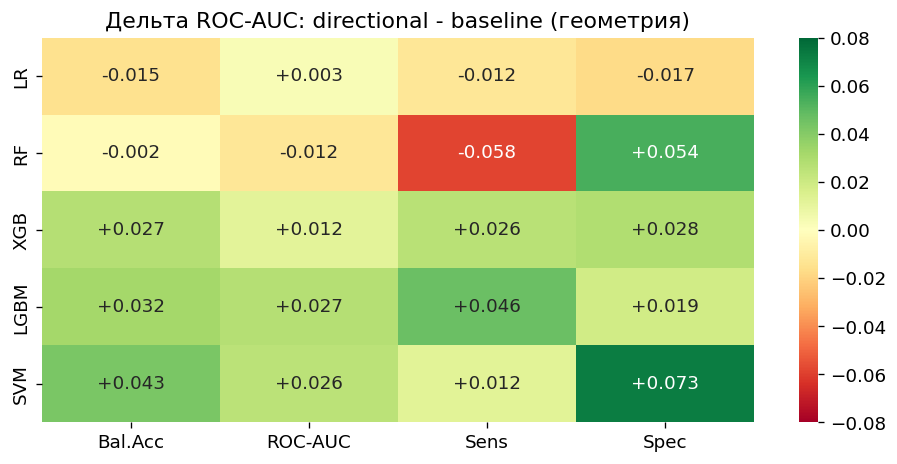

In [100]:
dir_rows = []
for label, data in dir_results.items():
    res = data['res']
    best_m = max(res, key=lambda m: res[m]['roc_auc'])
    dir_rows.append({
        'Конфигурация': label,
        'Признаков': data['nf'],
        'Лучшая модель': best_m,
        'ROC-AUC': round(res[best_m]['roc_auc'], 4),
        'Bal.Acc': round(res[best_m]['bal_acc'], 4),
        'Sens': round(res[best_m]['sens'], 4),
        'Spec': round(res[best_m]['spec'], 4),
    })
display(pd.DataFrame(dir_rows))

# Heatmap дельт: directional vs baseline
metrics_d = ['bal_acc','roc_auc','sens','spec']
labels_d  = ['Bal.Acc','ROC-AUC','Sens','Spec']
delta = np.zeros((len(model_names), len(metrics_d)))
for i, mn in enumerate(model_names):
    for j, met in enumerate(metrics_d):
        base_v = dir_results['Геом baseline']['res'][mn][met]
        dir_v  = dir_results['Геом directional']['res'][mn][met]
        delta[i, j] = dir_v - base_v

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(delta, xticklabels=labels_d, yticklabels=model_names,
            annot=True, fmt='+.3f', cmap='RdYlGn', center=0, vmin=-0.08, vmax=0.08, ax=ax)
ax.set_title('Дельта ROC-AUC: directional - baseline (геометрия)')
plt.tight_layout(); plt.show()


## 19. Стандартные методы отбора признаков sklearn

SelectKBest, SelectFromModel (L1-LogReg), RFE применяются внутри Pipeline на лучшей конфигурации.


In [102]:
def run_with_selector(selector, X, y, groups):
    cv_sel = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res_sel = {}
    for name, model in _make_models(y.values).items():
        pipe_sel = Pipeline([
            ('corr',   CorrelationFilter(0.95)),
            ('scaler', StandardScaler()),
            ('select', clone(selector) if selector is not None else 'passthrough'),
            ('model',  clone(model)),
        ])
        cvr = cross_validate(pipe_sel, X, y, groups=groups, cv=cv_sel,
                             scoring=scoring, return_train_score=False)
        res_sel[name] = {k: (np.mean(cvr[f'test_{k}']), np.std(cvr[f'test_{k}'])) for k in scoring}
    return res_sel

selector_results = {'Baseline (без отбора)': {mn: {'roc_auc':(best_res_bl2[mn]['roc_auc'], 0),
                                                    'balanced_accuracy':(best_res_bl2[mn]['bal_acc'],0),
                                                    'sensitivity':(best_res_bl2[mn]['sens'],0),
                                                    'specificity':(best_res_bl2[mn]['spec'],0)}
                                               for mn in model_names}}

for k in [10, 20, 50]:
    print(f'>>> SelectKBest k={k}')
    selector_results[f'SelectKBest k={k}'] = run_with_selector(
        SelectKBest(f_classif, k=k), X_best, y_best, groups_best)

print('>>> SelectFromModel (L1-LogReg)')
l1_est = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=5000,
                             class_weight='balanced', random_state=RANDOM_STATE)
selector_results['SelectFromModel L1'] = run_with_selector(
    SelectFromModel(l1_est), X_best, y_best, groups_best)

print('>>> RFE (n=20)')
rfe_est = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)
selector_results['RFE n=20'] = run_with_selector(
    RFE(estimator=rfe_est, n_features_to_select=20), X_best, y_best, groups_best)
print('Готово.')


>>> SelectKBest k=10
>>> SelectKBest k=20
>>> SelectKBest k=50
>>> SelectFromModel (L1-LogReg)
>>> RFE (n=20)
Готово.


,Configuration,Best Model,ROC-AUC,Bal.Acc,Sens,Spec
0,Baseline (без отбора),LGBM,0.905,0.826,0.934,0.718
1,SelectKBest k=10,LR,0.890,0.838,0.831,0.846
2,SelectKBest k=20,LR,0.885,0.806,0.839,0.773
3,SelectKBest k=50,LR,0.883,0.825,0.839,0.810
4,SelectFromModel L1,RF,0.872,0.780,0.845,0.716
5,RFE n=20,LGBM,0.885,0.813,0.872,0.755


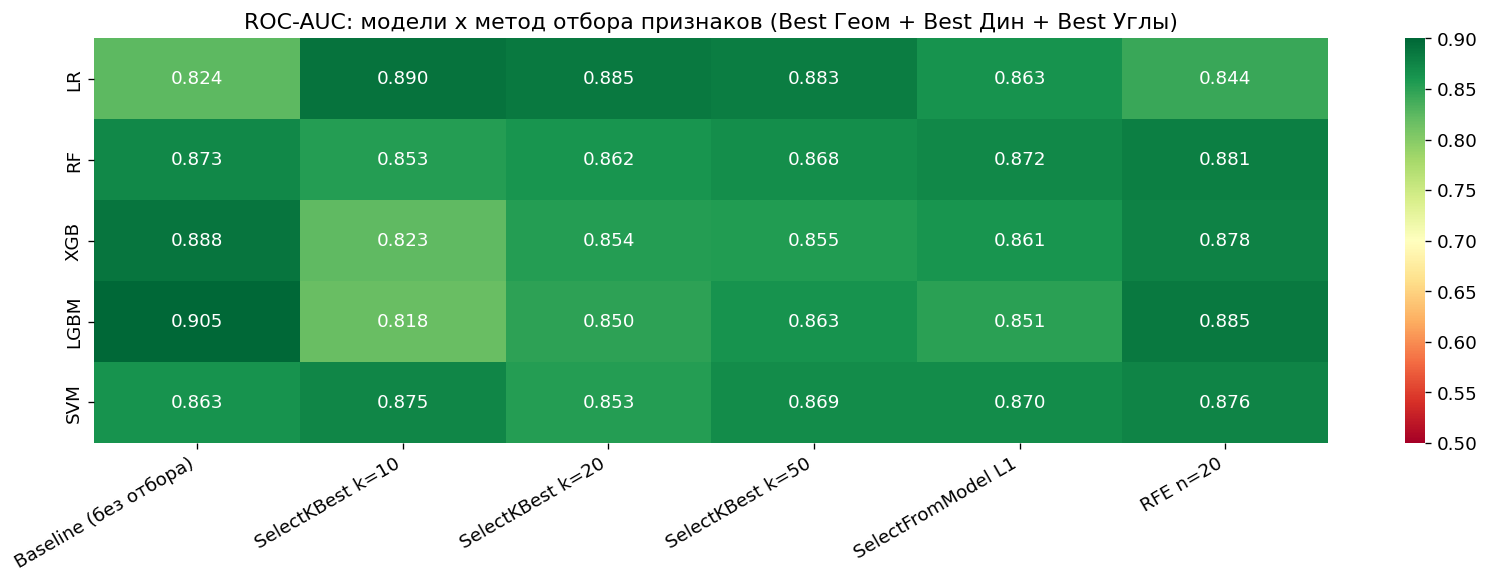

In [103]:
sel_rows = []
for conf_name, res in selector_results.items():
    bm = max(res, key=lambda m: res[m]['roc_auc'][0])
    r = res[bm]
    sel_rows.append({
        'Configuration': conf_name,
        'Best Model': bm,
        'ROC-AUC': f'{r["roc_auc"][0]:.3f}',
        'Bal.Acc': f'{r["balanced_accuracy"][0]:.3f}',
        'Sens':    f'{r["sensitivity"][0]:.3f}',
        'Spec':    f'{r["specificity"][0]:.3f}',
    })
display(pd.DataFrame(sel_rows))

# Heatmap
conf_names_sel = list(selector_results.keys())
hm_sel = np.zeros((len(model_names), len(conf_names_sel)))
for i, mn in enumerate(model_names):
    for j, cn in enumerate(conf_names_sel):
        hm_sel[i, j] = selector_results[cn][mn]['roc_auc'][0]
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(hm_sel, xticklabels=conf_names_sel, yticklabels=model_names,
            annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=0.9, ax=ax)
ax.set_title(f'ROC-AUC: модели x метод отбора признаков ({bl2_best_label})')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


## 20. Сводные результаты

In [105]:
def _best_auc(res):
    if isinstance(next(iter(res.values()))['roc_auc'], tuple):
        return max(res[m]['roc_auc'][0] for m in model_names)
    return max(res[m]['roc_auc'] for m in model_names)

summary_rows_final = [
    {'Конфигурация': 'Лучший одиночный аггрегат (геом)',
     'Значение': f'{max(geom_single[a]["res"][m]["roc_auc"] for a in geom_single for m in model_names):.3f}'},
    {'Конфигурация': 'Лучшая геом комбинация',
     'Значение': f'{_best_auc(geom_combos[geom_best_name]["res"]):.3f} ({geom_best_name})'},
    {'Конфигурация': 'Лучшая дин комбинация',
     'Значение': f'{_best_auc(dyn_combos[dyn_best_name]["res"]):.3f} ({dyn_best_name})'},
    {'Конфигурация': 'Лучшая угловая комбинация',
     'Значение': f'{_best_auc(ang_combos[ang_best_name]["res"]):.3f} ({ang_best_name})'},
    {'Конфигурация': 'Лучшая площадная комбинация',
     'Значение': f'{_best_auc(area_combos[area_best_name]["res"]):.3f} ({area_best_name})'},
    {'Конфигурация': f'Block 2 winner ({bl2_best_label})',
     'Значение': f'{df_summary_bl2.iloc[0]["ROC-AUC"]:.4f}'},
    {'Конфигурация': f'UMAP (лучший n={best_nc})',
     'Значение': f'{best_umap_auc:.3f}'},
    {'Конфигурация': 'SMOTE (лучший k)',
     'Значение': f'{best_smote_auc:.3f}'},
]
display(pd.DataFrame(summary_rows_final))


,Конфигурация,Значение
0,Лучший одиночный аггрегат (геом),0.767
1,Лучшая геом комбинация,0.798 (min_norm+std_norm)
2,Лучшая дин комбинация,0.891 (max_vel_norm+mean_vel_norm+std_vel_norm)
3,Лучшая угловая комбинация,0.701 (mean_angle+std_angle)
4,Лучшая площадная комбинация,0.787 (area_min+area_range)
5,Block 2 winner (Best Геом + Best Дин + Best Углы),0.9051
6,UMAP (лучший n=5),0.811
7,SMOTE (лучший k),0.900


## 21. Nested Cross-Validation — финальная оценка

Nested CV даёт несмещённую оценку качества модели с одновременным подбором гиперпараметров.

- **Внешний цикл**: `StratifiedGroupKFold(n_splits=5)` — пациент не попадает в train и test одновременно.
- **Внутренний цикл**: `GridSearchCV` с `StratifiedKFold(n_splits=3)` — поиск лучших гиперпараметров на train-части каждого внешнего фолда.

Конфигурация признаков: победитель Block 2 (`bl2_best_label`).

In [107]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grids = {
    'LR':   {'model__C': [0.01, 0.1, 1, 10]},
    'RF':   {'model__n_estimators': [100, 300], 'model__max_depth': [None, 5, 10]},
    'XGB':  {'model__learning_rate': [0.05, 0.1, 0.2],
              'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]},
    'LGBM': {'model__learning_rate': [0.05, 0.1],
              'model__num_leaves': [31, 63], 'model__n_estimators': [100, 200]},
    'SVM':  {'model__C': [0.1, 1, 10]},
}

outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

nested_results = {}
for mn, model in _make_models(y_best.values).items():
    pipe = Pipeline([
        ('corr',   CorrelationFilter(0.95)),
        ('scaler', StandardScaler()),
        ('model',  clone(model)),
    ])
    gs = GridSearchCV(pipe, param_grids[mn], cv=inner_cv,
                      scoring='roc_auc', n_jobs=-1, refit=True)
    outer_aucs = []
    for tr_idx, te_idx in outer_cv.split(X_best, y_best, groups_best):
        X_tr, y_tr = X_best.iloc[tr_idx], y_best.iloc[tr_idx]
        X_te, y_te = X_best.iloc[te_idx], y_best.iloc[te_idx]
        gs.fit(X_tr, y_tr)
        prob = gs.best_estimator_.predict_proba(X_te)[:, 1]
        outer_aucs.append(roc_auc_score(y_te, prob))
    nested_results[mn] = {
        'aucs': outer_aucs,
        'mean': round(float(np.mean(outer_aucs)), 4),
        'std':  round(float(np.std(outer_aucs)),  4),
    }
    print(f'{mn}: AUC = {np.mean(outer_aucs):.3f} \u00b1 {np.std(outer_aucs):.3f}')

LR: AUC = 0.840 ± 0.074
RF: AUC = 0.882 ± 0.053
XGB: AUC = 0.888 ± 0.045
LGBM: AUC = 0.900 ± 0.048
SVM: AUC = 0.841 ± 0.083


,Simple CV AUC,Nested CV AUC,Смещение
Модель,,,
LR,0.824,0.840 ± 0.074,+0.016
RF,0.873,0.882 ± 0.053,+0.008
XGB,0.888,0.888 ± 0.045,-0.001
LGBM,0.905,0.900 ± 0.048,-0.005
SVM,0.863,0.841 ± 0.083,-0.022


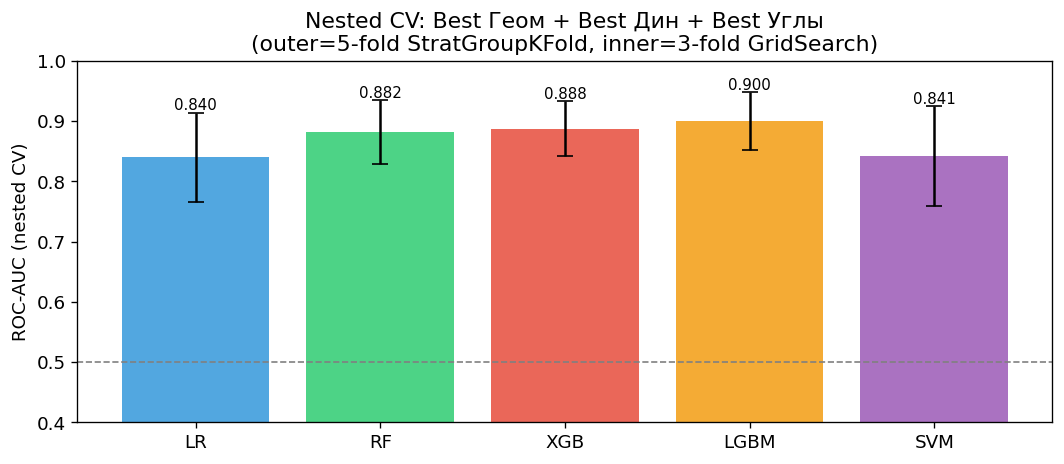


Лучшая модель (nested CV): LGBM — AUC=0.900 ± 0.048


In [108]:
# Таблица сравнения: простая CV vs nested CV
nested_rows = []
for mn in model_names:
    simple_auc = best_res_bl2[mn]['roc_auc']
    n = nested_results[mn]
    nested_rows.append({
        'Модель':         mn,
        'Simple CV AUC':  f'{simple_auc:.3f}',
        'Nested CV AUC':  f'{n["mean"]:.3f} \u00b1 {n["std"]:.3f}',
        '\u0421\u043c\u0435\u0449\u0435\u043d\u0438\u0435': f'{n["mean"] - simple_auc:+.3f}',
    })
nested_df = pd.DataFrame(nested_rows).set_index('\u041c\u043e\u0434\u0435\u043b\u044c')
display(nested_df)

# Barplot
best_nested = max(nested_results, key=lambda m: nested_results[m]['mean'])
fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = [colors_m[m] for m in model_names]
means = [nested_results[m]['mean'] for m in model_names]
stds  = [nested_results[m]['std']  for m in model_names]
ax.bar(model_names, means, yerr=stds, color=colors_bar, alpha=0.85,
       capsize=5, error_kw={'linewidth': 1.5})
ax.axhline(0.5, color='gray', lw=1, ls='--')
for i, (m, v, s) in enumerate(zip(model_names, means, stds)):
    ax.text(i, v + s + 0.005, f'{v:.3f}', ha='center', fontsize=13)
ax.set_ylabel('ROC-AUC (nested CV)')
ax.set_title(f'Nested CV: {bl2_best_label}\n(outer=5-fold StratGroupKFold, inner=3-fold GridSearch)')
ax.set_ylim(0.4, 1.0)
plt.tight_layout(); plt.show()
print(f'\n\u041b\u0443\u0447\u0448\u0430\u044f \u043c\u043e\u0434\u0435\u043b\u044c (nested CV): {best_nested} — AUC={nested_results[best_nested]["mean"]:.3f} \u00b1 {nested_results[best_nested]["std"]:.3f}')

## 23. Проверка устойчивости: только первая попытка (r = r0)

Среднее число retake: PD = 1.26, Healthy = 3.67.  
Потенциальный confounding: модель могла выучить «много retake → Healthy».

Проверка: обучаем и тестируем **только** на наблюдениях с `r = 'r0'` (первая попытка, есть у каждого пациента).  
Если AUC сохраняется — retake-confound отсутствует и результаты надёжны.


In [110]:
# Фильтрация: только первая попытка
df_r1      = df[df['r'] == 'r0'].copy()
df_wide_r1 = df_wide[df_wide['r'] == 'r0'].copy()

n_pd_r1 = df_r1[df_r1.label == 1]['Patient'].nunique()
n_hc_r1 = df_r1[df_r1.label == 0]['Patient'].nunique()
print(f'r0: {df_r1["Patient"].nunique()} пациентов ({n_pd_r1} PD / {n_hc_r1} Healthy)')
print(f'   строк в long: {len(df_r1)},  наблюдений в wide: {len(df_wide_r1)}')
print()

# Лучшая конфигурация Block 2 — воссоздаём из r0 данных
sub_r1 = df_r1[df_r1['Aggregate'].isin(dyn_best_list)]
pivot_r1 = sub_r1.pivot_table(
    index=['Patient', 'r', 'label'],
    columns='Aggregate', values=dist_cols, aggfunc='first')
pivot_r1.columns = [f'{f}_{a}' for f, a in pivot_r1.columns]
pivot_r1 = pivot_r1.reset_index()

feat_r1 = [c for c in pivot_r1.columns if c.startswith('dist_')]
X_r1, y_r1, g_r1 = pivot_r1[feat_r1], pivot_r1['label'], pivot_r1['Patient']
print(f'Признаков: {X_r1.shape[1]}, наблюдений: {X_r1.shape[0]}')
print()

res_r1, _ = run_models_xy(X_r1, y_r1, g_r1)

# Сравниваем с полным датасетом
r1_rows = []
for mn in model_names:
    full_auc = best_res_bl2[mn]['roc_auc']
    r1_auc   = res_r1[mn]['roc_auc']
    r1_rows.append({
        'Модель':           mn,
        'AUC (все retake)':  f'{full_auc:.3f}',
        'AUC (r0 only)':     f'{r1_auc:.3f}',
        'Δ':                 f'{r1_auc - full_auc:+.3f}',
        'Bal.Acc (r0)':      f'{res_r1[mn]["bal_acc"]:.3f}',
    })

r1_df = pd.DataFrame(r1_rows).set_index('Модель')
display(r1_df.style.set_caption(f'Устойчивость к r0 — {bl2_best_label}'))

best_r1_mn   = max(res_r1,       key=lambda m: res_r1[m]['roc_auc'])
best_full_mn = max(best_res_bl2, key=lambda m: best_res_bl2[m]['roc_auc'])
auc_r1_val   = res_r1[best_r1_mn]['roc_auc']
auc_full_val = best_res_bl2[best_full_mn]['roc_auc']
diff = auc_r1_val - auc_full_val

print(f'Лучший AUC (все retake): {auc_full_val:.3f} ({best_full_mn})')
print(f'Лучший AUC (r0 only):    {auc_r1_val:.3f} ({best_r1_mn})')
print(f'Δ = {diff:+.3f}')
print()
if abs(diff) < 0.05:
    print('Вывод: результаты стабильны — retake-confound отсутствует.')
else:
    print('Внимание: значительное расхождение — retake может быть confounding-фактором.')


r0: 151 пациентов (124 PD / 27 Healthy)
   строк в long: 1963,  наблюдений в wide: 151

Признаков: 186, наблюдений: 151



,AUC (все retake),AUC (r0 only),Δ,Bal.Acc (r0)
Модель,,,,
LR,0.824,0.789,-0.035,0.688
RF,0.873,0.698,-0.175,0.525
XGB,0.888,0.679,-0.209,0.590
LGBM,0.905,0.649,-0.256,0.577
SVM,0.863,0.711,-0.153,0.651


Лучший AUC (все retake): 0.905 (LGBM)
Лучший AUC (r0 only):    0.789 (LR)
Δ = -0.116

Внимание: значительное расхождение — retake может быть confounding-фактором.
